### 1. Import necessary libraries

In [554]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score 
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import RobustScaler
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier


### 2. Data Overview and Initial Data Inspection

The file name: bank-additional-full.csv\
The link to the data source: https://archive.ics.uci.edu/dataset/222/bank+marketing \
The file separated by ' ; '

In [555]:
# Import the csv file separating the data by ;
data = pd.read_csv('raw_data\\bank-additional-full.csv', sep=';')

In [556]:
df = pd.DataFrame(data)
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [557]:
print(f'Shape of the dataframe: (rows, columns): {df.shape}')

Shape of the dataframe: (rows, columns): (41188, 21)


In [558]:
print('Detailed information:\n')
df.info()

Detailed information:

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   411

In [559]:
print(f'Statistical summary of numerical columns:\n{df.describe()}')

Statistical summary of numerical columns:
               age      duration      campaign         pdays      previous  \
count  41188.00000  41188.000000  41188.000000  41188.000000  41188.000000   
mean      40.02406    258.285010      2.567593    962.475454      0.172963   
std       10.42125    259.279249      2.770014    186.910907      0.494901   
min       17.00000      0.000000      1.000000      0.000000      0.000000   
25%       32.00000    102.000000      1.000000    999.000000      0.000000   
50%       38.00000    180.000000      2.000000    999.000000      0.000000   
75%       47.00000    319.000000      3.000000    999.000000      0.000000   
max       98.00000   4918.000000     56.000000    999.000000      7.000000   

       emp.var.rate  cons.price.idx  cons.conf.idx     euribor3m   nr.employed  
count  41188.000000    41188.000000   41188.000000  41188.000000  41188.000000  
mean       0.081886       93.575664     -40.502600      3.621291   5167.035911  
std        1

In [560]:
print('Basic summary of categorical columns (object data type)')
df.describe(include=[object,"string"])

Basic summary of categorical columns (object data type)


,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome,y
count,41188,41188,41188,41188,41188,41188,41188,41188,41188,41188,41188
unique,12,4,8,3,3,3,2,10,5,3,2
top,admin.,married,university.degree,no,yes,no,cellular,may,thu,nonexistent,no
freq,10422,24928,12168,32588,21576,33950,26144,13769,8623,35563,36548


In [561]:
print('Class balance:')
df['y'].value_counts()

Class balance:


y
no     36548
yes     4640
Name: count, dtype: int64

### 3. Split DataFrame into training DataFrame and testing DataFrame

To prevent data leakage, the dataset is split into training and testing dataframes at this stage before any cleaninig and preprocessing is performed. This is ensure that preprocessing decidions are based only on the training data, allowing test dataset to remaing unseen until later stages of model development.\
\
Cross validation will be perfomed later in the stage therefore data split at this stage is only training and testing data.

In [562]:
# Split the dataframe into training dataframe and testing dataframe (testing data = 20%) 
# to have two complete dataframes (training df and testing df) to perform data cleaning and data preprocessing.
# Set stratified split to make the proportion of classes in the target variable will be preserved in both the training and testing sets.

train_df, test_df = train_test_split(df, test_size=0.2, stratify=df['y'], random_state=42)

# Make copy of the 2 dataframes and keep it just in case original splited dataframe is required.
train_df_original = train_df.copy()
test_df_original = test_df.copy()

### 4. Data Preprocessing

Preprocessing will be performed on train_df.\
\
4.1 Data profiling
- 4.1.1 Data size and structure
- 4.1.2 Content overview
- 4.1.3 Missing values / 'unknown' values
- 4.1.4 Duplicate records
- 4.1.5 Format inconsistency (Whitespace)

4.1.1 Data size and structure

In [563]:
train_df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
25611,49,blue-collar,married,basic.9y,unknown,no,no,cellular,nov,wed,...,4,999,0,nonexistent,-0.1,93.200,-42.0,4.120,5195.8,no
26010,37,entrepreneur,married,university.degree,no,no,no,telephone,nov,wed,...,2,999,1,failure,-0.1,93.200,-42.0,4.120,5195.8,no
40194,78,retired,married,basic.4y,no,no,no,cellular,jul,mon,...,1,999,0,nonexistent,-1.7,94.215,-40.3,0.870,4991.6,yes
297,36,admin.,married,university.degree,no,yes,no,telephone,may,mon,...,2,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
36344,59,retired,divorced,university.degree,no,no,no,cellular,jun,tue,...,2,999,0,nonexistent,-2.9,92.963,-40.8,1.262,5076.2,no


In [564]:
print(f'Shape of the training dataframe: (rows, columns): {train_df.shape}')

Shape of the training dataframe: (rows, columns): (32950, 21)


In [565]:
print('Detailed information of the training dataframe:\n')
train_df.info()

Detailed information of the training dataframe:

<class 'pandas.DataFrame'>
Index: 32950 entries, 25611 to 10747
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             32950 non-null  int64  
 1   job             32950 non-null  str    
 2   marital         32950 non-null  str    
 3   education       32950 non-null  str    
 4   default         32950 non-null  str    
 5   housing         32950 non-null  str    
 6   loan            32950 non-null  str    
 7   contact         32950 non-null  str    
 8   month           32950 non-null  str    
 9   day_of_week     32950 non-null  str    
 10  duration        32950 non-null  int64  
 11  campaign        32950 non-null  int64  
 12  pdays           32950 non-null  int64  
 13  previous        32950 non-null  int64  
 14  poutcome        32950 non-null  str    
 15  emp.var.rate    32950 non-null  float64
 16  cons.price.idx  32950 non-null  float64

4.1.2 Content Overview

In [566]:
print(f'Statistical summary of numerical columns in the training dataframe:\n{train_df.describe()}')

Statistical summary of numerical columns in the training dataframe:
                age      duration      campaign         pdays      previous  \
count  32950.000000  32950.000000  32950.000000  32950.000000  32950.000000   
mean      40.014112    258.127466      2.560607    962.052413      0.174719   
std       10.403636    258.975917      2.752326    187.951096      0.499025   
min       17.000000      0.000000      1.000000      0.000000      0.000000   
25%       32.000000    103.000000      1.000000    999.000000      0.000000   
50%       38.000000    180.000000      2.000000    999.000000      0.000000   
75%       47.000000    319.000000      3.000000    999.000000      0.000000   
max       98.000000   4918.000000     56.000000    999.000000      7.000000   

       emp.var.rate  cons.price.idx  cons.conf.idx     euribor3m   nr.employed  
count  32950.000000    32950.000000   32950.000000  32950.000000  32950.000000  
mean       0.080470       93.575881     -40.508489      3.

In [567]:
print('Basic summary of categorical columns (object data type) in training dataframe')
train_df.describe(include=[object,"string"])

Basic summary of categorical columns (object data type) in training dataframe


,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome,y
count,32950,32950,32950,32950,32950,32950,32950,32950,32950,32950,32950
unique,12,4,8,3,3,3,2,10,5,3,2
top,admin.,married,university.degree,no,yes,no,cellular,may,thu,nonexistent,no
freq,8314,19953,9736,26007,17254,27131,20908,11011,6857,28416,29238


In [568]:
# Count how many unique values in each categorical variable
# This is an extraction of Basic summary of categorical columns (object data type) 
# in training dataframe which has been already performed in the earlier section.
train_df.select_dtypes(include=['object', 'string']).nunique()

job            12
marital         4
education       8
default         3
housing         3
loan            3
contact         2
month          10
day_of_week     5
poutcome        3
y               2
dtype: int64

In [569]:
# Select only categorical variables and change from a pandas series to a list
categorical_variables = pd.Series(train_df.select_dtypes(include=['object', 'string']).columns).tolist()
print(f'Categorical variables:\n{categorical_variables}')

# Get unique values of each categorical variable
print('\nUnique values in each categorical variables')
for category in categorical_variables:
    print(f'\n{category}:\n{train_df[category].unique()}')

Categorical variables:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'y']

Unique values in each categorical variables

job:
<StringArray>
[  'blue-collar',  'entrepreneur',       'retired',        'admin.',
       'student',      'services',    'technician', 'self-employed',
    'management',    'unemployed',       'unknown',     'housemaid']
Length: 12, dtype: str

marital:
<StringArray>
['married', 'divorced', 'single', 'unknown']
Length: 4, dtype: str

education:
<StringArray>
[           'basic.9y',   'university.degree',            'basic.4y',
         'high.school', 'professional.course',             'unknown',
            'basic.6y',          'illiterate']
Length: 8, dtype: str

default:
<StringArray>
['unknown', 'no', 'yes']
Length: 3, dtype: str

housing:
<StringArray>
['no', 'yes', 'unknown']
Length: 3, dtype: str

loan:
<StringArray>
['no', 'yes', 'unknown']
Length: 3, dtype: str

contact:
<StringArray>
['cellul

4.1.3 Missing values and 'unknown' values

- Check missing values: The document stated no missing value so this is to confirm that there is no missing value.

- Check 'unknown' values:\
The document stated that there are several missing values in some categorical attributes, \
all coded with the "unknown" label.\
Calculate the proportion of the 'unknown' values to decide how to deal with it later.

In [570]:
# Check missing values
train_df.isnull().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

In [571]:
# Check 'unknown' values
print((train_df=='unknown').sum())

age                  0
job                265
marital             65
education         1397
default           6940
housing            796
loan               796
contact              0
month                0
day_of_week          0
duration             0
campaign             0
pdays                0
previous             0
poutcome             0
emp.var.rate         0
cons.price.idx       0
cons.conf.idx        0
euribor3m            0
nr.employed          0
y                    0
dtype: int64


In [572]:
# Check how much percentages does each 'unknown' values in each category where thre are 'unknown' values.
print('\'Unknown\' values in each category with count and proportion(%):')

# Check 'unknown' values count in the training dataframe
unknown_counts = (train_df == 'unknown').sum()
# Calculate the percentage of 'unknown' values
unknown_percentage = ((unknown_counts / len(train_df))*100).round(2)
# Make DataFrame to see the summary of 'unknown' values in each category containing 'unknown' value
unknown_summary_df = pd.DataFrame({
    'Unknown Count': unknown_counts,
    'Unknown Percentage (%)': unknown_percentage
})

unknown_summary_df = unknown_summary_df[unknown_summary_df['Unknown Count'] > 0]

display(unknown_summary_df)

'Unknown' values in each category with count and proportion(%):


,Unknown Count,Unknown Percentage (%)
job,265,0.80
marital,65,0.20
education,1397,4.24
default,6940,21.06
housing,796,2.42
loan,796,2.42


4.1.4 Duplicate records

In [573]:
# Check duplication
train_df.duplicated().sum()
train_df

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
25611,49,blue-collar,married,basic.9y,unknown,no,no,cellular,nov,wed,...,4,999,0,nonexistent,-0.1,93.200,-42.0,4.120,5195.8,no
26010,37,entrepreneur,married,university.degree,no,no,no,telephone,nov,wed,...,2,999,1,failure,-0.1,93.200,-42.0,4.120,5195.8,no
40194,78,retired,married,basic.4y,no,no,no,cellular,jul,mon,...,1,999,0,nonexistent,-1.7,94.215,-40.3,0.870,4991.6,yes
297,36,admin.,married,university.degree,no,yes,no,telephone,may,mon,...,2,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
36344,59,retired,divorced,university.degree,no,no,no,cellular,jun,tue,...,2,999,0,nonexistent,-2.9,92.963,-40.8,1.262,5076.2,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40205,28,services,single,high.school,no,yes,no,cellular,jul,tue,...,1,999,0,nonexistent,-1.7,94.215,-40.3,0.876,4991.6,no
27316,52,technician,married,professional.course,no,yes,no,cellular,nov,fri,...,1,999,1,failure,-0.1,93.200,-42.0,4.021,5195.8,no
14392,54,admin.,married,basic.9y,no,no,yes,cellular,jul,mon,...,4,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
7494,29,admin.,married,university.degree,no,no,no,telephone,may,fri,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.864,5191.0,no


In [574]:
# Extract all the duplicated rows
duplicates = train_df[train_df.duplicated(keep=False)]
duplicates.sort_values(by=train_df.columns.tolist())

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
32505,35,admin.,married,university.degree,no,yes,no,cellular,may,fri,...,4,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
32516,35,admin.,married,university.degree,no,yes,no,cellular,may,fri,...,4,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
12260,36,retired,married,unknown,no,no,no,telephone,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.966,5228.1,no
12261,36,retired,married,unknown,no,no,no,telephone,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.966,5228.1,no
25183,39,admin.,married,university.degree,no,no,no,cellular,nov,tue,...,2,999,0,nonexistent,-0.1,93.200,-42.0,4.153,5195.8,no
25217,39,admin.,married,university.degree,no,no,no,cellular,nov,tue,...,2,999,0,nonexistent,-0.1,93.200,-42.0,4.153,5195.8,no
1266,39,blue-collar,married,basic.6y,no,no,no,telephone,may,thu,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
1265,39,blue-collar,married,basic.6y,no,no,no,telephone,may,thu,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
20531,41,technician,married,professional.course,no,yes,no,cellular,aug,tue,...,1,999,0,nonexistent,1.4,93.444,-36.1,4.966,5228.1,no
20534,41,technician,married,professional.course,no,yes,no,cellular,aug,tue,...,1,999,0,nonexistent,1.4,93.444,-36.1,4.966,5228.1,no


4.1.5 Format inconsistency (Whitespace)

In [575]:
# Check for whitespace issue in categorical variables
for column in categorical_variables:
    values_whitespace = [value for value in df[column] if value.startswith(' ') or value.endswith(' ')]
    if len(values_whitespace) > 0:
        print(f'{column}: {values_whitespace}')
    else:
        print(f'{column}: No whitespace issue')

job: No whitespace issue
marital: No whitespace issue
education: No whitespace issue
default: No whitespace issue
housing: No whitespace issue
loan: No whitespace issue
contact: No whitespace issue
month: No whitespace issue
day_of_week: No whitespace issue
poutcome: No whitespace issue
y: No whitespace issue


4.2 Preprocessing decisions
- 4.2.1 'unknown' values
- 4.2.2 Duplicated records
- 4.2.3 Encoding
- 4.2.4 Class imbalance

4.2.1 'unknown' values\
\
When checked 'unknown' values, there were several categories with 'unknown' values as stated in the document.\
The summary of the finding is as below.\
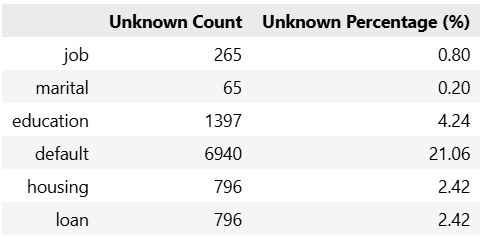

- job, marital: less than 1%\
Imputation method will be applied with the most frequent values as the impact will be minimum using SimpleImputer.\(strategy='most_frequent) later.\
\
- housing, loan: less than 3 %\
The 'unknown' values were in the same rows for both columns.\
This indicates that the bank did not record housing and loan information for the same customers.
Imputation method will still be applied with the most frequent values as the impact will be minimum using SimpleImputer.
This is based on the investigation whether 'unknown' have almost exactly the same subscription rate as the majority category.\
\
- education: less than 5%\
Even though the 'unknown' values in education is less than 5%, if SimpleIputer with most frequent value applied, university.degree appearance goes up by 14%. This will potentially distort the original distribution about customers' educatoin level. Therefore  the 'unknown' values in education will be retained to avoid introducing unsupported assumptions about customers' education levels.\
\
- default: over 20%\
The default = no and target = yes category contains 12.9% within the whole the default = no category while the unknown category with target = yes showed a substantially lower subscription rate (5.2%) within the whole unknown category. This indicates that the unknown values contain useful information and should be retained as a separate category rather than being replaced with the most frequent value.


In [576]:
# Counts values in each column to see if imputing the most frequent values for 'unknown' value is adequet or not.
unknown_less_than_5pct = ['job', 'marital', 'education', 'housing', 'loan']

for category in unknown_less_than_5pct:
    print(f'{train_df[category].value_counts(dropna=False)}\n')

# train_df['job'].value_counts(dropna=False)

job
admin.           8314
blue-collar      7441
technician       5400
services         3196
management       2345
retired          1366
entrepreneur     1160
self-employed    1099
housemaid         855
unemployed        798
student           711
unknown           265
Name: count, dtype: int64

marital
married     19953
single       9257
divorced     3675
unknown        65
Name: count, dtype: int64

education
university.degree      9736
high.school            7596
basic.9y               4826
professional.course    4192
basic.4y               3322
basic.6y               1865
unknown                1397
illiterate               16
Name: count, dtype: int64

housing
yes        17254
no         14900
unknown      796
Name: count, dtype: int64

loan
no         27131
yes         5023
unknown      796
Name: count, dtype: int64



In [577]:
# Check to see if 'unknown' values appears in the same rows for loan and housing.
# Further investigation is performed because the number of 'unknown' value counts are the exactly the same.

(train_df['housing']=='unknown').equals(train_df['loan']=='unknown')
# ((train_df['housing']=='unknown') & (train_df['loan']=='unknown')).sum()

True

In [578]:
# Check if unknown value in housing and the unknown value in education have any obvious relationship
housing_unknown_df = train_df[train_df['housing']=='unknown']
display(housing_unknown_df.head(3))

print('Counts of customers who has housing loan in each education level:')
groupby_education = housing_unknown_df.groupby('education')['housing'].count() # picked 'housing column to get the full rows but no meaning of the column selection.

display(groupby_education)

# # create a new df to see the comparison in percentage 
# groupby_education_pct_df = groupby_education.to_frame()
# display(groupby_education_pct_df)

# for e in groupby_education_pct_df.index:
#     groupby_education_pct_df.loc[e, 'percent'] = groupby_education_pct_df.loc[e, 'housing'] / groupby_education_pct_df['housing'].sum()*100

# display(groupby_education_pct_df)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
19678,48,blue-collar,married,unknown,unknown,unknown,unknown,cellular,aug,thu,...,3,999,0,nonexistent,1.4,93.444,-36.1,4.968,5228.1,no
494,32,admin.,single,university.degree,unknown,unknown,unknown,telephone,may,tue,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
40273,77,retired,married,basic.4y,no,unknown,unknown,cellular,jul,tue,...,2,3,1,success,-1.7,94.215,-40.3,0.893,4991.6,yes


Counts of customers who has housing loan in each education level:


education
basic.4y                97
basic.6y                47
basic.9y               123
high.school            183
professional.course     94
university.degree      219
unknown                 33
Name: housing, dtype: int64

In [579]:
# Check if unknown value in housing and the unknown value in job have any obvious relationship
print('Counts of customers who has housing loan in each job:')
groupby_job = housing_unknown_df.groupby('job')['housing'].count() # picked 'housing column to get the full rows but no meaning of the column selection.

display(groupby_job)

Counts of customers who has housing loan in each job:


job
admin.           181
blue-collar      197
entrepreneur      27
housemaid         24
management        58
retired           32
self-employed     35
services          80
student           17
technician       120
unemployed        21
unknown            4
Name: housing, dtype: int64

In [580]:
# Check the subscription rate with housing vs y

housing_loan_y_df = train_df[['housing', 'loan', 'y']]
# display(housing_loan_y_df.head(3))

housing_y = housing_loan_y_df.groupby(['housing', 'y'])['y'].count()
# display(housing_y)

# create a new df to see the comparison in percentage 
groupby_housing_y_df = housing_y.to_frame()
# display(groupby_housing_y_df)

# Calculate the proportion of yes and no in each housing yes, no, unknown category 
# to see if the unknown yes, no proportion are the same ratio as the other categories.
for index in groupby_housing_y_df.index:
    housing_rows = groupby_housing_y_df[groupby_housing_y_df.index.get_level_values('housing') == index[0]]
    housing_level_sum = housing_rows['y'].sum()
    # print(index, housing_level_sum)
    groupby_housing_y_df.loc[index, 'percent'] = groupby_housing_y_df.loc[index, 'y'] / housing_level_sum*100

display(groupby_housing_y_df)


y    percent
housing y                    
no      no   13272  89.073826
        yes   1628  10.926174
unknown no     706  88.693467
        yes     90  11.306533
yes     no   15260  88.443260
        yes   1994  11.556740

In [581]:
# Check the subscription rate with loan vs y

loan_y = housing_loan_y_df.groupby(['loan', 'y'])['y'].count()
# display(loan_y)

# create a new df to see the comparison in percentage 
groupby_loan_y_df = loan_y.to_frame()
# display(groupby_loan_y_df)

# Calculate the proportion of yes and no in each housing yes, no, unknown category 
# to see if the unknown yes, no proportion are the same ratio as the other categories.
for index in groupby_loan_y_df.index:
    loan_rows = groupby_loan_y_df[groupby_loan_y_df.index.get_level_values('loan') == index[0]]
    loan_level_sum = loan_rows['y'].sum()
    groupby_loan_y_df.loc[index, 'percent'] = groupby_loan_y_df.loc[index, 'y'] / loan_level_sum*100
    # print(index, loan_level_sum)

display(groupby_loan_y_df)

y    percent
loan    y                    
no      no   24073  88.728760
        yes   3058  11.271240
unknown no     706  88.693467
        yes     90  11.306533
yes     no    4459  88.771650
        yes    564  11.228350

In [582]:
# Check the proportion of all the category values in default.
train_df['default'].value_counts(normalize=True)*100

default
no         78.928680
unknown    21.062215
yes         0.009105
Name: proportion, dtype: float64

In [583]:
# Check the subscription rate with default vs y

default_y_df = train_df[['default', 'y']]
display(default_y_df.head(3))

default_y = default_y_df.groupby(['default', 'y'])['y'].count()
# display(default_y)

# create a new df to see the comparison in percentage 
groupby_default_y_df = default_y.to_frame()
# display(groupby_default_y_df)

# Calculate the proportion of yes and no in each housing yes, no, unknown category 
# to see if the unknown yes, no proportion are the same ratio as the other categories.
for index in groupby_default_y_df.index:
    default_rows = groupby_default_y_df[groupby_default_y_df.index.get_level_values('default') == index[0]]
    default_level_sum = default_rows['y'].sum()
    # print(index, loan_level_sum)
    groupby_default_y_df.loc[index, 'percent'] = groupby_default_y_df.loc[index, 'y'] / default_level_sum*100

display(groupby_default_y_df)

,default,y
25611,unknown,no
26010,no,no
40194,no,yes


y     percent
default y                     
no      no   22656   87.115007
        yes   3351   12.884993
unknown no    6579   94.798271
        yes    361    5.201729
yes     no       3  100.000000

4.2.2 Duplicate handling\
\
Eight completely duplicated records were identified in the training dataset. Althogh these could represent data entry errors, the dataset does not contain a unique customer identifier or timestamp to determine they are accidental duplicates or lefitimate repeated obsercations from separate telephone contacts. Given that they represent only approximately 0.02% of the training data, they were retained to avoid removing potentially valid observations.

4.2.3 Encoding\
\
Encoding will be performed only for categorical variables excluding y (target) leaving it 'yes'/'no' for now.\
One thing to note, initially pd.get_dummies(), however, after more research about one hot encoding, OneHotEncoder from scikit-learn can handle potential new categories in test dataset. Therefore OneHotEncoding will be performed.


In [584]:
# Investigate categorical variables excluding y (target).
train_df.drop(columns='y').select_dtypes(include=['object', 'string']).columns

Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome'],
      dtype='str')

4.2.4 Class imbalance\
\
The target variable is imbalanced, with approximately 89% of customers not subscribing to a term deposit\
and 11% subscribing as shown in below cell.\
This class imbalance will be considered during model development and evaluation.

In [585]:
# Compare yes and no proportion in each original dataframe, training dataframe and testing dataframe.
whole_df = (df['y'].value_counts(normalize=True)*100).round(2)
training_df = (train_df['y'].value_counts(normalize=True)*100).round(2)
testing_df = (test_df['y'].value_counts(normalize=True)*100).round(2)

class_balance_summary = pd.DataFrame({
    'Whole df': whole_df,
    'Training df' : training_df,
    'Testing df' : testing_df
})

class_balance_summary

,Whole df,Training df,Testing df
y,,,
no,88.73,88.73,88.74
yes,11.27,11.27,11.26


4.3 Preprocessing\
\
Now the decisions were made based on the data shown the above section, the decisions to be applied to preprocess the data.\
\
4.3.1 Impute unknown values\
4.3.2 Encolding

4.3.1 Impute unknown values\
\
Imputation will be applied with the most frequent values for job, marital, housing and loan.\
Simpleimputater with strategy='most_frequent' is applied for those 4 categories as below.
- job: admin.
- marital: married
- housing: yes
- loan: no

Before SimpleImputer applied, the 'unknown' value need to be replace as NaN for the function to pick up missing values.

In [586]:
# Create the copy of train_df to work on the imputation method.
mode_impute_columns_df = train_df.copy()

# Replace 'unknown' with NaN for 'job', 'marital', 'housing', 'loan' columns as SimpleImputer picks the missing values
mode_impute_columns = ['job', 'marital', 'housing', 'loan']
for col in mode_impute_columns:
    mode_impute_columns_df.loc[mode_impute_columns_df[col] == 'unknown', col] = np.nan

# Compare the unknown counts before and after replacing with NaN
print('Table showing unknown counts before replacing with Nan:')
display(unknown_summary_df)

print('Unknown counts after replacing with Nan:')
display((mode_impute_columns_df == 'unknown').sum())

print('Counts for missing values after replaced with NaN:')
display(mode_impute_columns_df.isnull().sum())

Table showing unknown counts before replacing with Nan:


,Unknown Count,Unknown Percentage (%)
job,265,0.80
marital,65,0.20
education,1397,4.24
default,6940,21.06
housing,796,2.42
loan,796,2.42


Unknown counts after replacing with Nan:


age                  0
job                  0
marital              0
education         1397
default           6940
housing              0
loan                 0
contact              0
month                0
day_of_week          0
duration             0
campaign             0
pdays                0
previous             0
poutcome             0
emp.var.rate         0
cons.price.idx       0
cons.conf.idx        0
euribor3m            0
nr.employed          0
y                    0
dtype: int64

Counts for missing values after replaced with NaN:


age                 0
job               265
marital            65
education           0
default             0
housing           796
loan              796
contact             0
month               0
day_of_week         0
duration            0
campaign            0
pdays               0
previous            0
poutcome            0
emp.var.rate        0
cons.price.idx      0
cons.conf.idx       0
euribor3m           0
nr.employed         0
y                   0
dtype: int64

In [587]:
# Imputation for missing values with mode method

mode_impute_columns_df_original = mode_impute_columns_df.copy() 

mode_imputer = SimpleImputer(strategy='most_frequent')
mode_impute_columns_df[['job', 'marital', 'housing', 'loan']] = mode_imputer.fit_transform(mode_impute_columns_df[['job', 'marital', 'housing', 'loan']])

# display(mode_impute_columns_df)
print('Check any missing values after imputed:')
display(mode_impute_columns_df.isnull().sum())

print('Compare before and after imputation in dataframe:')
display(mode_impute_columns_df_original.compare(mode_impute_columns_df))

print('Dataframe after imputed:')
display(mode_impute_columns_df)

Check any missing values after imputed:


age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

Compare before and after imputation in dataframe:


job         marital          housing       loan      
      self   other    self    other    self other self other
23737  NaN  admin.     NaN      NaN     NaN   NaN  NaN   NaN
19678  NaN     NaN     NaN      NaN     NaN   yes  NaN    no
494    NaN     NaN     NaN      NaN     NaN   yes  NaN    no
40273  NaN     NaN     NaN      NaN     NaN   yes  NaN    no
7011   NaN  admin.     NaN      NaN     NaN   NaN  NaN   NaN
...    ...     ...     ...      ...     ...   ...  ...   ...
4454   NaN     NaN     NaN  married     NaN   NaN  NaN   NaN
33351  NaN     NaN     NaN      NaN     NaN   yes  NaN    no
23912  NaN     NaN     NaN      NaN     NaN   yes  NaN    no
6421   NaN     NaN     NaN      NaN     NaN   yes  NaN    no
29     NaN  admin.     NaN      NaN     NaN   yes  NaN    no

[1113 rows x 8 columns]

Dataframe after imputed:


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
25611,49,blue-collar,married,basic.9y,unknown,no,no,cellular,nov,wed,...,4,999,0,nonexistent,-0.1,93.200,-42.0,4.120,5195.8,no
26010,37,entrepreneur,married,university.degree,no,no,no,telephone,nov,wed,...,2,999,1,failure,-0.1,93.200,-42.0,4.120,5195.8,no
40194,78,retired,married,basic.4y,no,no,no,cellular,jul,mon,...,1,999,0,nonexistent,-1.7,94.215,-40.3,0.870,4991.6,yes
297,36,admin.,married,university.degree,no,yes,no,telephone,may,mon,...,2,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
36344,59,retired,divorced,university.degree,no,no,no,cellular,jun,tue,...,2,999,0,nonexistent,-2.9,92.963,-40.8,1.262,5076.2,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40205,28,services,single,high.school,no,yes,no,cellular,jul,tue,...,1,999,0,nonexistent,-1.7,94.215,-40.3,0.876,4991.6,no
27316,52,technician,married,professional.course,no,yes,no,cellular,nov,fri,...,1,999,1,failure,-0.1,93.200,-42.0,4.021,5195.8,no
14392,54,admin.,married,basic.9y,no,no,yes,cellular,jul,mon,...,4,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
7494,29,admin.,married,university.degree,no,no,no,telephone,may,fri,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.864,5191.0,no


4.3.2 Encoding\
\
OneHotEncoding is applied to convert categorical variables into binary columns for machine learning models.\
'y' column is left out from encoding as this is the target column.

In [588]:
# Create a dataframe with only categorical columns dropping 'y' column
categorical_columns_df = train_df.select_dtypes(include=['object', 'string']).drop('y', axis='columns')

categorical_columns_df.head()

,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome
25611,blue-collar,married,basic.9y,unknown,no,no,cellular,nov,wed,nonexistent
26010,entrepreneur,married,university.degree,no,no,no,telephone,nov,wed,failure
40194,retired,married,basic.4y,no,no,no,cellular,jul,mon,nonexistent
297,admin.,married,university.degree,no,yes,no,telephone,may,mon,nonexistent
36344,retired,divorced,university.degree,no,no,no,cellular,jun,tue,nonexistent


In [589]:
# Create the origianl encoded_df to keep
categorical_columns_df_original = categorical_columns_df.copy()

In [590]:
# Apply OneHotEncoder
categorical_columns = categorical_columns_df.columns
# print(categorical_columns)
encoder = OneHotEncoder(sparse_output=False)
encoded_data = encoder.fit_transform(categorical_columns_df[categorical_columns])

encoded_df = pd.DataFrame(
    encoded_data,
    columns=encoder.get_feature_names_out(categorical_columns)
)
print('Dataframe after OneHotEncoder applied:')
display(encoded_df.head())

display(encoded_df.info())

Dataframe after OneHotEncoder applied:


,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,...,month_oct,month_sep,day_of_week_fri,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_failure,poutcome_nonexistent,poutcome_success
0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


<class 'pandas.DataFrame'>
RangeIndex: 32950 entries, 0 to 32949
Data columns (total 53 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   job_admin.                     32950 non-null  float64
 1   job_blue-collar                32950 non-null  float64
 2   job_entrepreneur               32950 non-null  float64
 3   job_housemaid                  32950 non-null  float64
 4   job_management                 32950 non-null  float64
 5   job_retired                    32950 non-null  float64
 6   job_self-employed              32950 non-null  float64
 7   job_services                   32950 non-null  float64
 8   job_student                    32950 non-null  float64
 9   job_technician                 32950 non-null  float64
 10  job_unemployed                 32950 non-null  float64
 11  job_unknown                    32950 non-null  float64
 12  marital_divorced               32950 non-null  float64
 1

None

Put mode_impute_columns_df and encoded_df into one dataframe to make the final dataframe after preprocessing data.

In [591]:
# concat mode_impute_columns_df and encoded_df

print(f'Rows count for imputed df: {len(mode_impute_columns_df.drop(columns=categorical_columns))}')
print(f'Rows count for encoded df: {len(encoded_df)}')

encoded_df.index=mode_impute_columns_df.index
clean_train_df = pd.concat(
    [mode_impute_columns_df.drop(columns=categorical_columns), encoded_df], axis=1
)

print(f'Rows count for clean train df: {len(clean_train_df)}\n')

print('clean_train_df with one-hot encoded data:')
display(clean_train_df)

clean_train_df.isnull().sum()

Rows count for imputed df: 32950
Rows count for encoded df: 32950
Rows count for clean train df: 32950

clean_train_df with one-hot encoded data:


,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,...,month_oct,month_sep,day_of_week_fri,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_failure,poutcome_nonexistent,poutcome_success
25611,49,227,4,999,0,-0.1,93.200,-42.0,4.120,5195.8,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
26010,37,202,2,999,1,-0.1,93.200,-42.0,4.120,5195.8,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
40194,78,1148,1,999,0,-1.7,94.215,-40.3,0.870,4991.6,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
297,36,120,2,999,0,1.1,93.994,-36.4,4.857,5191.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
36344,59,368,2,999,0,-2.9,92.963,-40.8,1.262,5076.2,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40205,28,192,1,999,0,-1.7,94.215,-40.3,0.876,4991.6,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
27316,52,64,1,999,1,-0.1,93.200,-42.0,4.021,5195.8,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
14392,54,131,4,999,0,1.4,93.918,-42.7,4.962,5228.1,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
7494,29,165,1,999,0,1.1,93.994,-36.4,4.864,5191.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


age                     0
duration                0
campaign                0
pdays                   0
previous                0
                       ..
day_of_week_tue         0
day_of_week_wed         0
poutcome_failure        0
poutcome_nonexistent    0
poutcome_success        0
Length: 64, dtype: int64

### 5. Exploratory Data Analysis

- Target variable distribution
- Age distribution
- Duration vs Subscription
- Job vs Subscription
- Education vs Subscription

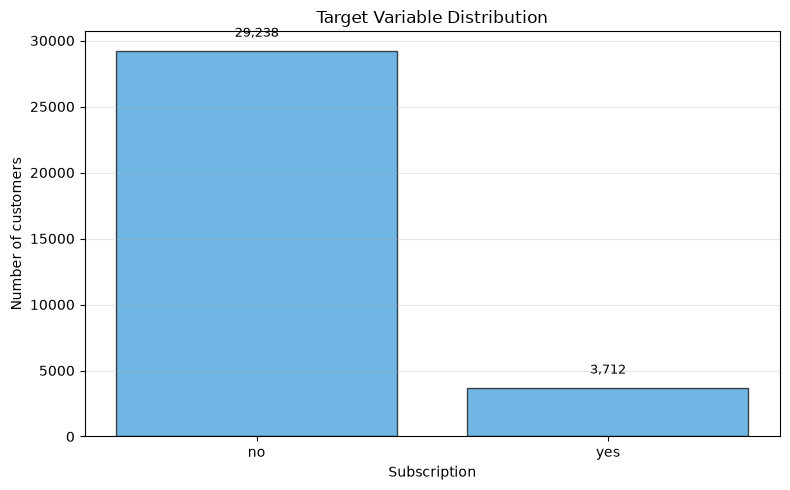

In [592]:
# Target variable distribution with bar chart comparing yes and no
x = ['no', 'yes']
y = [(clean_train_df['y'] =='no').sum(),
     (clean_train_df['y'] == 'yes').sum()
]

plt.figure(figsize=(8, 5))
plt.bar(x, y, alpha = 0.7, color='#3498DB', edgecolor='black', linewidth=1)
plt.title('Target Variable Distribution')
plt.xlabel('Subscription')
plt.ylabel('Number of customers')
plt.grid(True, axis='y', alpha=0.3)

for i, v in enumerate(y):
    plt.annotate(f'{v:,}',(i, v), textcoords='offset points', xytext=(0,10), ha='center', fontsize=9)

plt.tight_layout()

plt.show()

[49, 37, 78, 36, 59, 29, 26, 30, 50, 33, 44, 32, 26, 43, 56, 40, 32, 47, 50, 34, 46, 39, 41, 30, 55, 33, 46, 38, 36, 30, 34, 63, 46, 44, 55, 32, 34, 33, 34, 23, 39, 30, 41, 55, 30, 48, 36, 46, 48, 36, 53, 56, 48, 35, 50, 32, 37, 56, 35, 51, 51, 44, 36, 36, 47, 30, 32, 39, 71, 34, 32, 58, 21, 39, 39, 39, 45, 40, 49, 48, 25, 49, 33, 35, 33, 36, 49, 30, 77, 34, 48, 44, 50, 49, 28, 50, 40, 48, 32, 29, 29, 55, 45, 52, 32, 38, 33, 29, 37, 80, 57, 37, 40, 43, 22, 41, 35, 37, 44, 32, 60, 36, 51, 36, 46, 30, 33, 36, 27, 37, 50, 37, 24, 31, 30, 33, 49, 49, 31, 30, 29, 41, 40, 41, 42, 37, 34, 51, 39, 33, 39, 27, 36, 43, 42, 35, 28, 47, 55, 34, 34, 44, 39, 49, 36, 37, 37, 40, 59, 49, 53, 57, 43, 54, 51, 35, 53, 53, 34, 50, 39, 27, 27, 44, 29, 42, 31, 29, 60, 28, 28, 40, 35, 36, 36, 49, 47, 29, 35, 33, 28, 44, 34, 48, 38, 39, 35, 26, 48, 41, 37, 38, 45, 45, 36, 45, 45, 35, 40, 38, 39, 52, 37, 33, 33, 49, 38, 34, 38, 56, 30, 24, 36, 40, 29, 29, 46, 51, 27, 58, 29, 43, 34, 27, 53, 44, 30, 32, 30, 46,

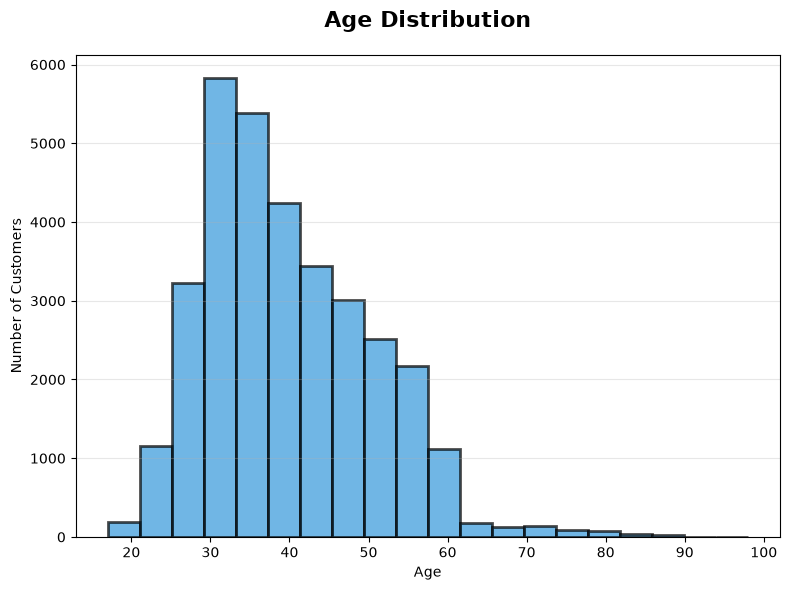

In [593]:
# Age distribution

# Histogram of age distribution
age_list = clean_train_df['age'].to_list()
print(age_list)

plt.figure(figsize=(8, 6))
plt.hist(age_list, bins=20, alpha=0.7, color='#3498DB', edgecolor='black', linewidth=2)
plt.title('Age Distribution', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Age')
plt.ylabel('Number of Customers')
plt.grid(True, axis='y', alpha=0.3)

plt.tight_layout()

plt.show()

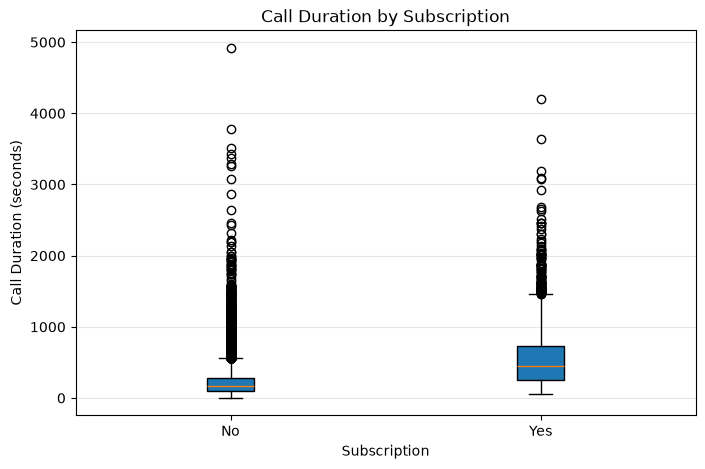

In [594]:
# Duration vs Subscription with boxpplot

duration_no = clean_train_df[clean_train_df['y'] == 'no']['duration'].to_list()
duration_yes = clean_train_df[clean_train_df['y'] == 'yes']['duration'].to_list()
# print(duration_no)
# print(duration_yes)

# combine the data
data = [duration_no, duration_yes]

# Create the boxplot
plt.figure(figsize=(8, 5))
plt.boxplot(
    data,
    tick_labels=['No', 'Yes'],
    patch_artist=True
)

plt.title('Call Duration by Subscription')
plt.xlabel('Subscription')
plt.ylabel('Call Duration (seconds)')
plt.grid(axis='y', alpha=0.3)
plt.show()

In [595]:
# Job vs Subscription

# clean_train_df has separated the categorical columns so mode_impute_colums_df is being used to create the graph.
job_y = mode_impute_columns_df.groupby(['job', 'y'])['y'].count()
# display(job_y)

# create a new df to see the comparison in percentage
groupby_job_y_df = job_y.to_frame()
# display(groupby_job_y_df)

# Calculate the proportion of yes and no in each job with yes, no category 
for index in groupby_job_y_df.index:
    job_rows = groupby_job_y_df[groupby_job_y_df.index.get_level_values('job') == index[0]]
    job_level_sum = job_rows['y'].sum()
    # print(index, job_level_sum)
    groupby_job_y_df.loc[index, 'percent'] = groupby_job_y_df.loc[index, 'y'] / job_level_sum*100

# display(groupby_job_y_df)

# Filter only yes to subscription rows
groupby_job_y_yes_df = groupby_job_y_df[ groupby_job_y_df.index.get_level_values('y') == 'yes']
display(groupby_job_y_yes_df)

,,y,percent
job,y,,
admin.,yes,1103,12.856976
blue-collar,yes,515,6.921113
entrepreneur,yes,100,8.620690
housemaid,yes,86,10.058480
management,yes,269,11.471215
retired,yes,348,25.475842
self-employed,yes,119,10.828025
services,yes,254,7.947434
student,yes,217,30.520394


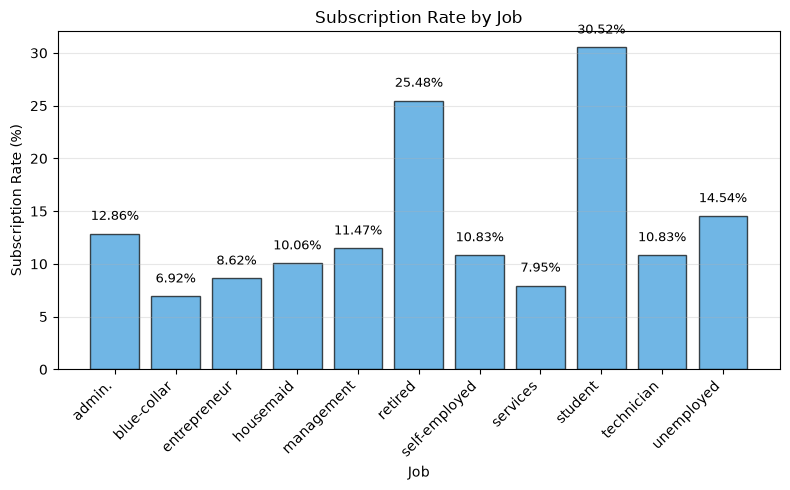

In [596]:
# Create the bar chart for Jobs vs Subscription

x = groupby_job_y_yes_df.index.get_level_values('job')
y = groupby_job_y_yes_df['percent']

plt.figure(figsize=(8, 5))
plt.bar(x, y, alpha = 0.7, color='#3498DB', edgecolor='black', linewidth=1)
plt.title('Subscription Rate by Job')
plt.xlabel('Job')
plt.ylabel('Subscription Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.grid(True, axis='y', alpha=0.3)

for i, v in enumerate(y):
    plt.annotate(f'{v:.2f}%',(i, v), textcoords="offset points", xytext=(0,10), ha='center', fontsize=9)

plt.tight_layout()

plt.show()

In [597]:
# Education Level vs Subscription

# clean_train_df has separated the categorical columns so mode_impute_colums_df is being used to create the graph.
education_y = mode_impute_columns_df.groupby(['education', 'y'])['y'].count()
# display(education_y)

# create a new df to see the comparison in percentage
groupby_education_y_df = education_y.to_frame()
# display(groupby_education_y_df)

# Calculate the proportion of yes and no in each education level with yes, no category 
for index in groupby_education_y_df.index:
    education_rows = groupby_education_y_df[groupby_education_y_df.index.get_level_values('education') == index[0]]
    education_level_sum = education_rows['y'].sum()
    # print(index, education_level_sum)
    groupby_education_y_df.loc[index, 'percent'] = groupby_education_y_df.loc[index, 'y'] / education_level_sum*100

display(groupby_education_y_df)

# Filter only yes to subscription rows
groupby_education_y_yes_df = groupby_education_y_df[ groupby_education_y_df.index.get_level_values('y') == 'yes']
display(groupby_education_y_yes_df)

y    percent
education           y                   
basic.4y            no   2978  89.644792
                    yes   344  10.355208
basic.6y            no   1709  91.635389
                    yes   156   8.364611
basic.9y            no   4457  92.353916
                    yes   369   7.646084
high.school         no   6781  89.270669
                    yes   815  10.729331
illiterate          no     13  81.250000
                    yes     3  18.750000
professional.course no   3719  88.716603
                    yes   473  11.283397
university.degree   no   8391  86.185292
                    yes  1345  13.814708
unknown             no   1190  85.182534
                    yes   207  14.817466

,,y,percent
education,y,,
basic.4y,yes,344,10.355208
basic.6y,yes,156,8.364611
basic.9y,yes,369,7.646084
high.school,yes,815,10.729331
illiterate,yes,3,18.750000
professional.course,yes,473,11.283397
university.degree,yes,1345,13.814708
unknown,yes,207,14.817466


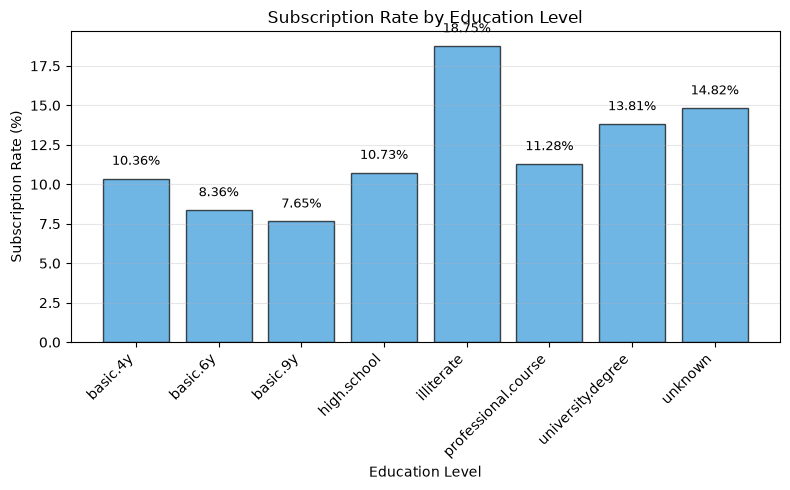

In [598]:
# Create the bar chart for Education vs Subscription

x = groupby_education_y_yes_df.index.get_level_values('education')
y = groupby_education_y_yes_df['percent']

plt.figure(figsize=(8, 5))
plt.bar(x, y, alpha = 0.7, color='#3498DB', edgecolor='black', linewidth=1)
plt.title('Subscription Rate by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Subscription Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.grid(True, axis='y', alpha=0.3)

for i, v in enumerate(y):
    plt.annotate(f'{v:.2f}%',(i, v), textcoords="offset points", xytext=(0,10), ha='center', fontsize=9)

plt.tight_layout()

plt.show()

### 6. Further analysis before preprocessing the whole training dataset

6.1.1 Further analysis on numerical variables\
\
Since Logistic Regression, Support Vector Machines and KNN are being considered for training the model, numeric variables need to be scaled. From EDA findings, there are outliers in the numerical variables, therefore futher examination is needed for all the numerical variables.\
\
Note: The Duration variable will not be used for training models as this colum was recorded only after the phone call had occured and therefore cannot be used to predict as stated in the document and also in the report submitted earlier.

In [599]:
clean_train_df.head(3)
clean_train_df.info()

<class 'pandas.DataFrame'>
Index: 32950 entries, 25611 to 10747
Data columns (total 64 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   age                            32950 non-null  int64  
 1   duration                       32950 non-null  int64  
 2   campaign                       32950 non-null  int64  
 3   pdays                          32950 non-null  int64  
 4   previous                       32950 non-null  int64  
 5   emp.var.rate                   32950 non-null  float64
 6   cons.price.idx                 32950 non-null  float64
 7   cons.conf.idx                  32950 non-null  float64
 8   euribor3m                      32950 non-null  float64
 9   nr.employed                    32950 non-null  float64
 10  y                              32950 non-null  str    
 11  job_admin.                     32950 non-null  float64
 12  job_blue-collar                32950 non-null  float64
 13

In [600]:
# Quick check which colums were originally numerical columns
# train_df.info()

Boxplot of the numerical variables in the training dataset:


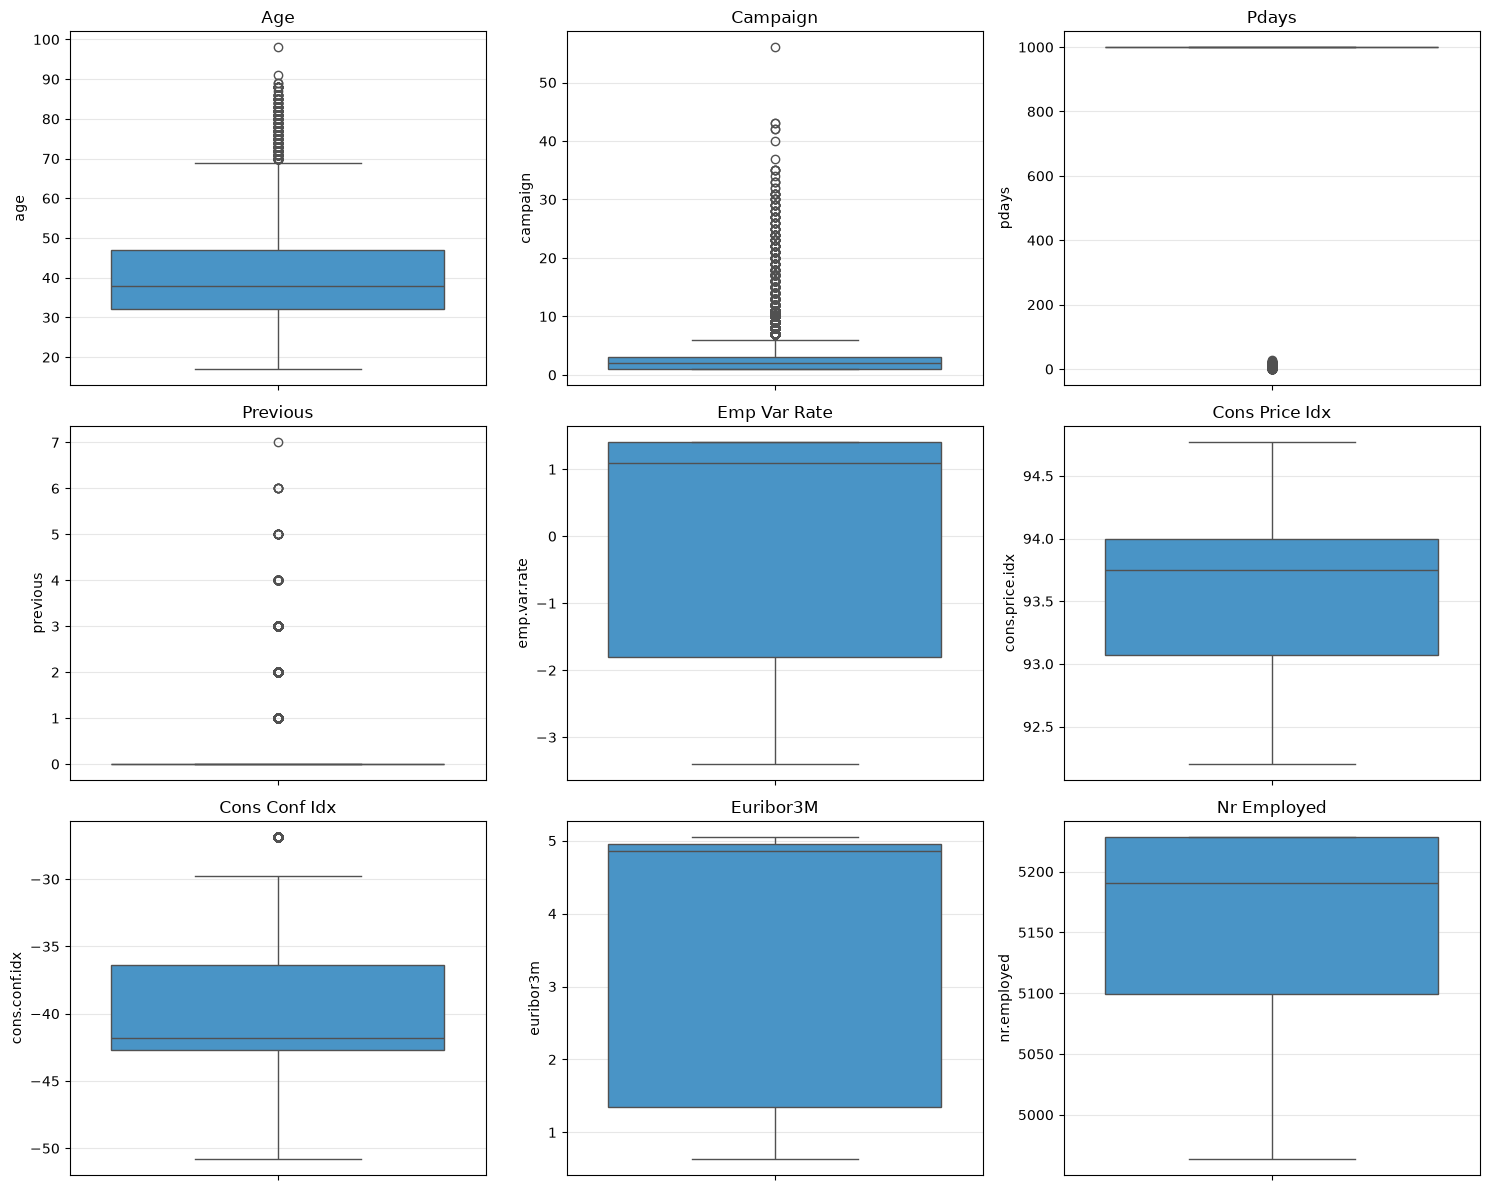

In [601]:
# Check the outliers in the original numerical columns, 
# ['campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

# Boxpplot to check the outliers of all the above numerical variables.
print('Boxplot of the numerical variables in the training dataset:')
numerical_variables = ['age', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, variable in enumerate(numerical_variables):
    sns.boxplot(y=clean_train_df[variable], ax=axes[i], color='#3498DB', patch_artist=True)
    axes[i].set_title(variable.replace('.', ' ').title())
    axes[i].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


Distribution of age, campaign, pdays and previous columns in the training dataset:


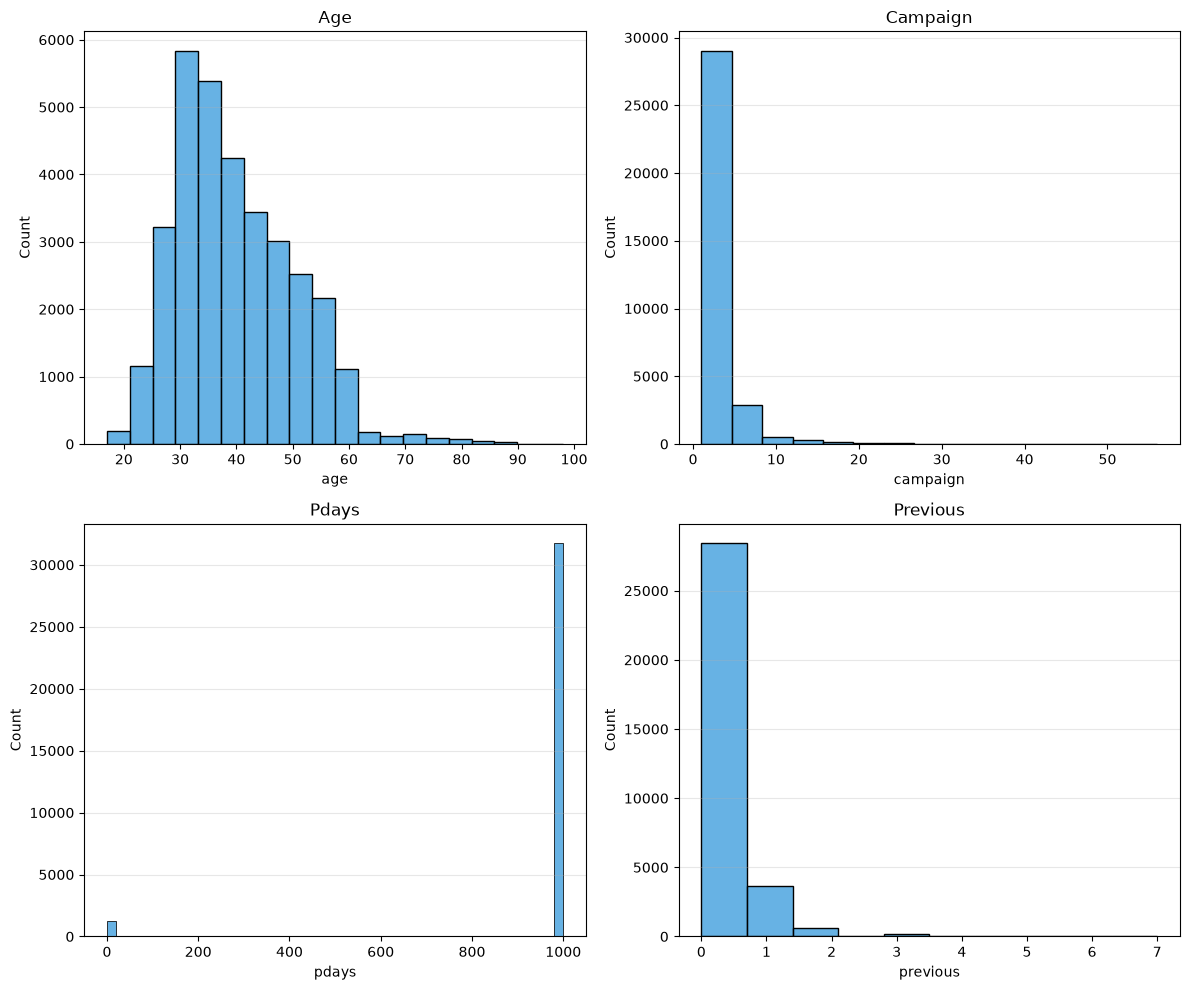

In [ ]:
# Further analysis in the columns, age, campaign, pdays and previous

# Histogram to check the distribution of the columns which indicate the potential outliers with boxplots.
print('Distribution of age, campaign, pdays and previous columns in the training dataset:')
hist_variables = ['age', 'campaign', 'pdays', 'previous']
bins_dict = {
    'age': 20,
    'campaign': 15,
    'pdays': 50,
    'previous': 10
}

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, variable in enumerate(hist_variables):
    sns.histplot(data=clean_train_df, x=variable, bins=bins_dict[variable], ax=axes[i], color='#3498DB')
    axes[i].set_title(variable.title())
    axes[i].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# During the data profiling on training dataset (section 4.1.2), 
# outliers were indicated in campaign and boxplot and histogram confirmed the potential outliers as well, so further indication was carried out for campaign.  
# clean_train_df.sort_values('campaign', ascending=False).head(20)

call_counts = [5, 10, 20, 30]
for call in call_counts:
    customer_count = (clean_train_df['campaign'] > call).sum()
    percentage = (customer_count / len(clean_train_df))*100
    print(f'{customer_count:,.0f} customers ({percentage:.2f}%) were contacted more than {call} times ')

2,689 customers (8.16%) were contacted more than 5 times 
687 customers (2.08%) were contacted more than 10 times 
124 customers (0.38%) were contacted more than 20 times 
24 customers (0.07%) were contacted more than 30 times 


Conclusion on the numerical variables\
\
Although some numerical variables contained outliers, all observations were retained because they represented valid values.\
Therefore, RobustScaler, which uses the median and the interquartile range (IQR) and is less sensitive to outliers, \
will be selected to reduce the influence of extreme values during model training and the feature scaling performed.

6.2.2 Correlation analysis on the numerical variables\
\
To understand the correlation between numerical features helps identify potential multicollinearity issues\
and also understand any relationships between features.

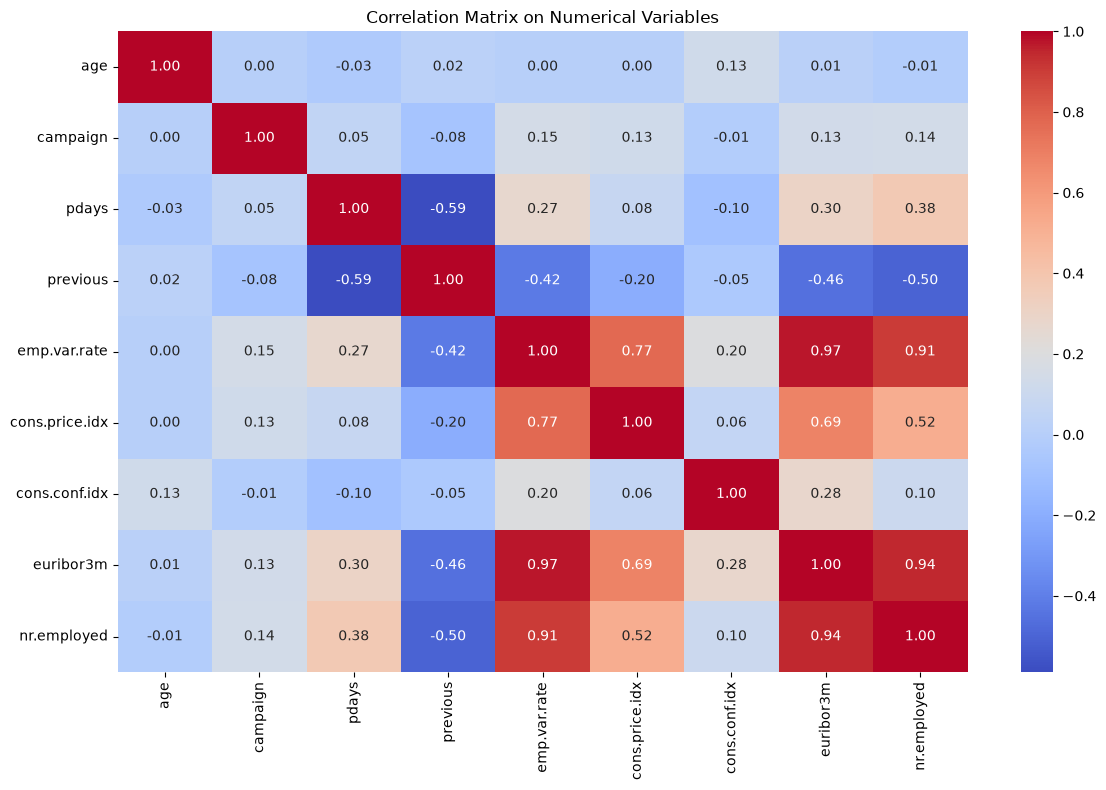

In [604]:
numerical_variables = ['age', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
corr_matrix = clean_train_df[numerical_variables].corr()

# Plot the heatmap of correlations
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix on Numerical Variables')
plt.tight_layout()
plt.show()

Most numerical variables have weak correlations with one another. However, a few macroeconomic indicators show strong positive correlations. In particular, emp.var.rate, euribor3m, and nr.employed have correlation coefficients above 0.90, suggesting potential multicollinearity. The variables are retained at this stage because they represent different economic measures. Their contribution to model performance will be evaluated during model development.

6.2.3 Further analysis on cagtegorical variables\
\
To understand the relationship between the categorical variables and the target, stacked bar charts were plotted to see\
if there are strong indicators of subscription with each categorical variable vs subscription results\
showing the proportion of subscription (dark blue for yes and light blue for no).\
\
Categorical variables were analysed using both customer counts and within-category subscription rates.\
The percentage plots supported comparison across categories of different sizes,\
while the count plots were used to identify categories with small sample sizes whose subscription rates could otherwise be misleading.\
\
mode_impute_columns_df which is one step before categorical varibles encoded, is being used for this analysis. 

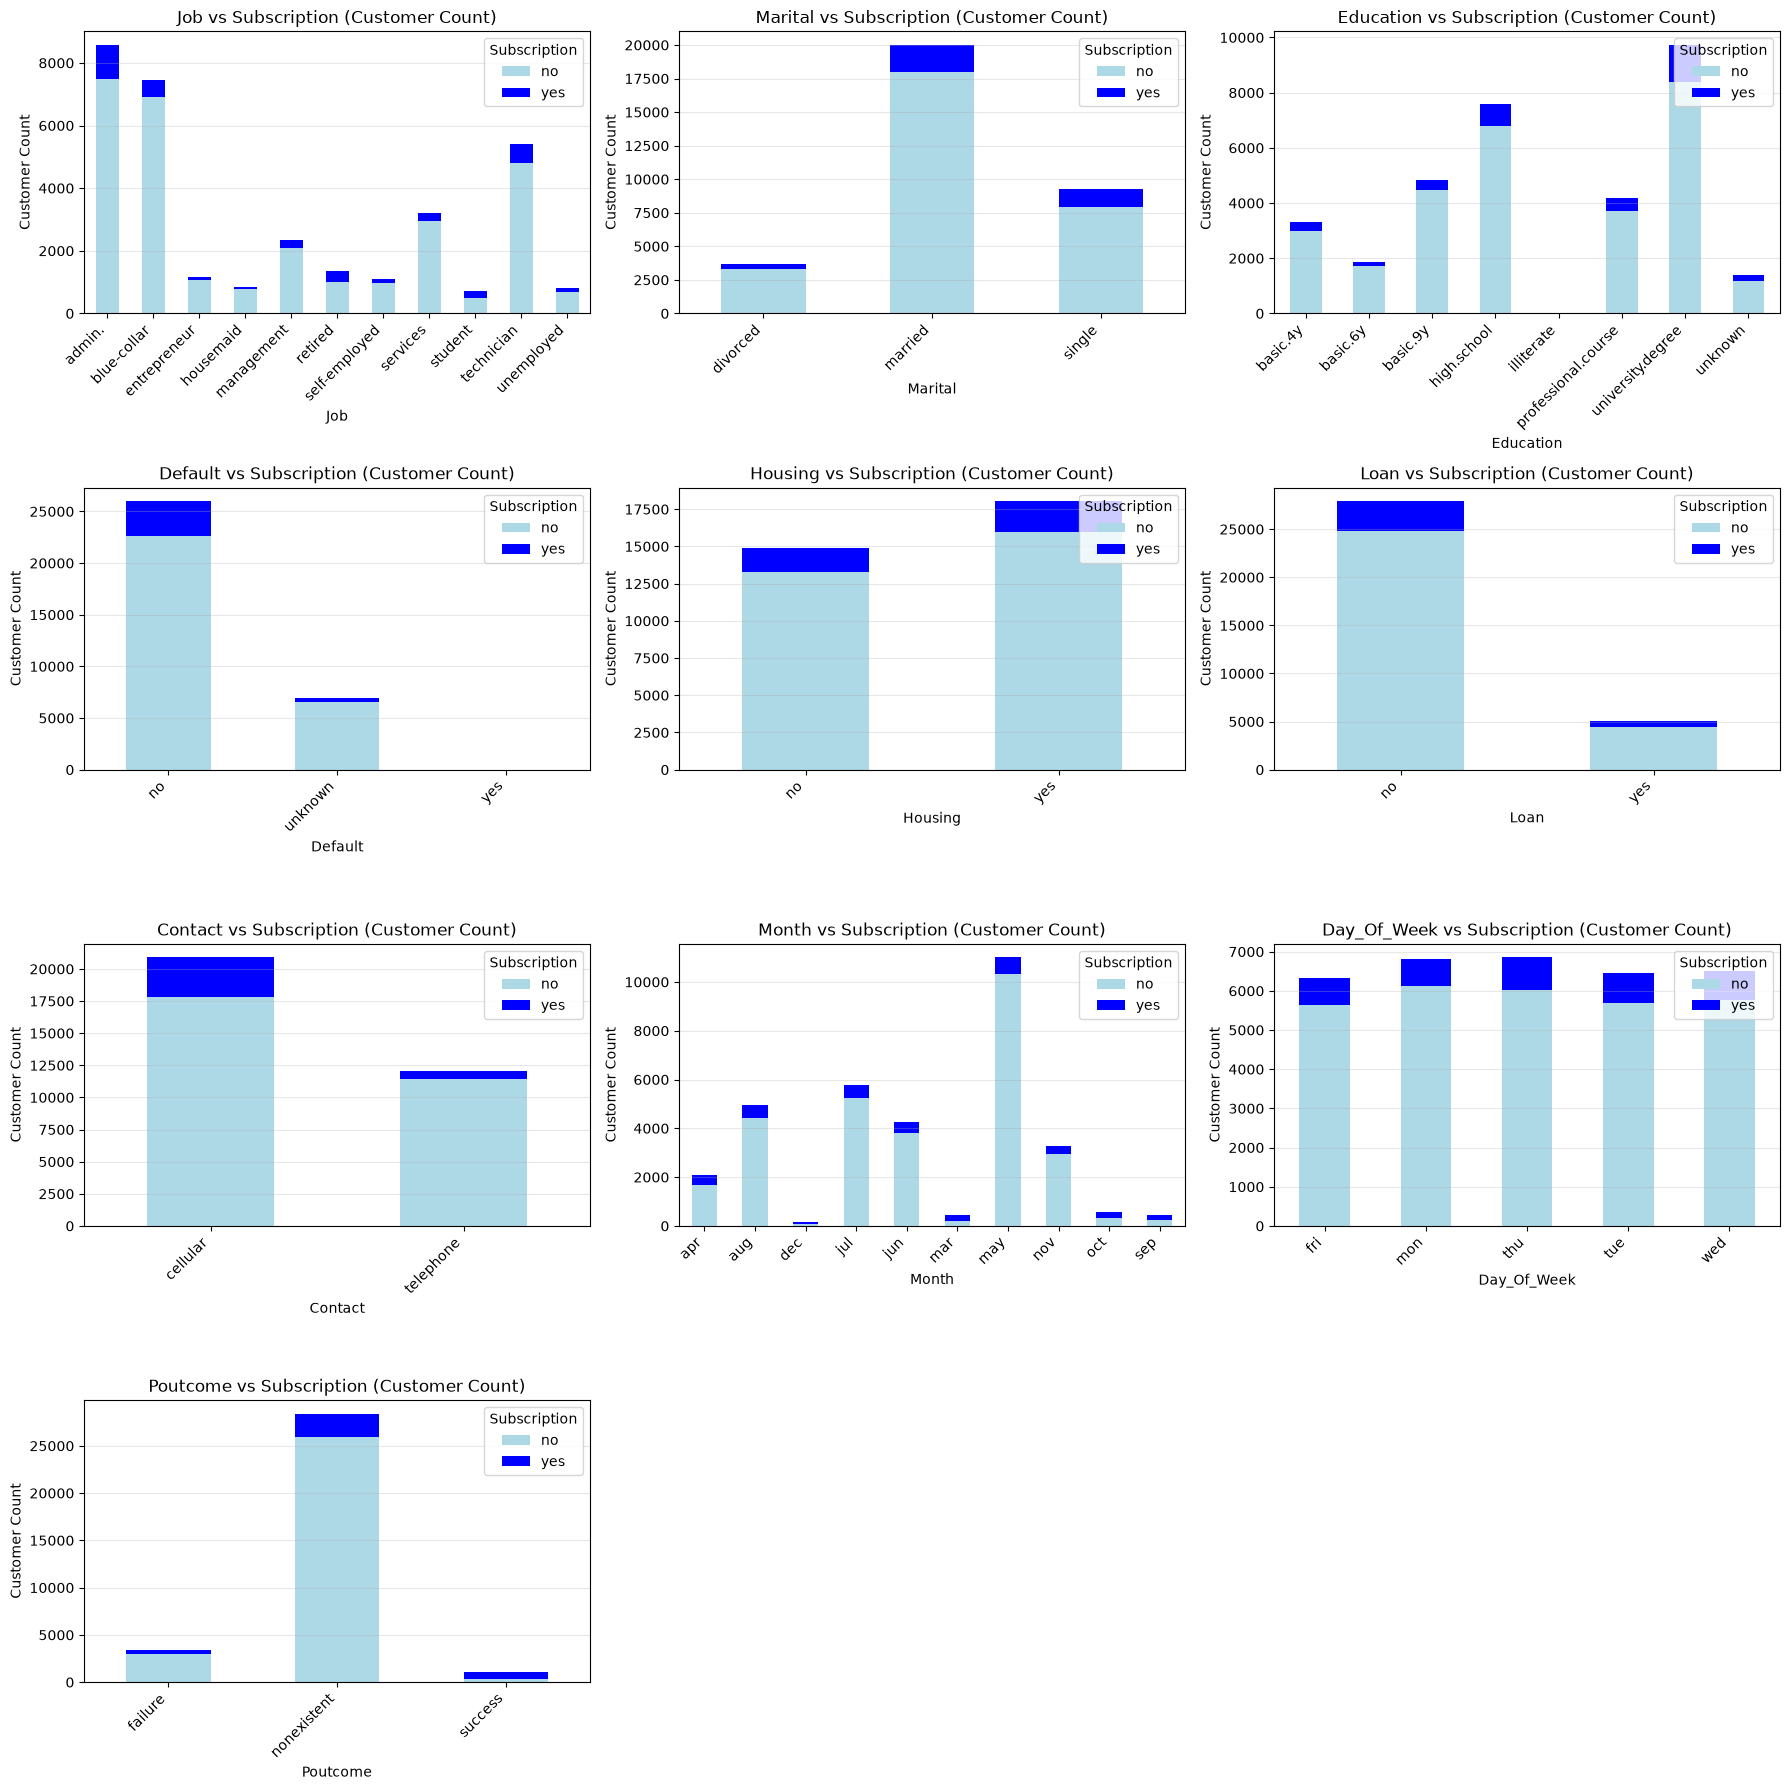

In [605]:
# Plot the categorical variables with stacked bar chart for customer count
# mode_impute_columns_df.head(3)

categorical_features = mode_impute_columns_df.drop(columns=['y']).select_dtypes(include=['object', 'string']).columns
# display(categorical_features)

fig, axes = plt.subplots(4, 3, figsize=(18, 18))
fig.subplots_adjust(hspace=0.6, wspace=0.6)
axes = axes.flatten()

palette = {'yes': 'blue', 'no': 'lightblue' }

for i, feature in enumerate(categorical_features):
    # If a category has no records for a target class, replace the empty value with 0.
    temp_df = mode_impute_columns_df.groupby([feature, 'y']).size().unstack().fillna(0)

    temp_df.plot(kind='bar', stacked=True, color=palette, ax=axes[i])
    axes[i].set_title(f'{feature.title()} vs Subscription (Customer Count)')
    axes[i].set_ylabel('Customer Count')
    axes[i].set_xlabel(feature.title())
    axes[i].legend(title='Subscription', loc='upper right')
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45, ha='right')    
    axes[i].grid(axis='y', alpha=0.3)

# Remove unused subplot spaces
for j in range (i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

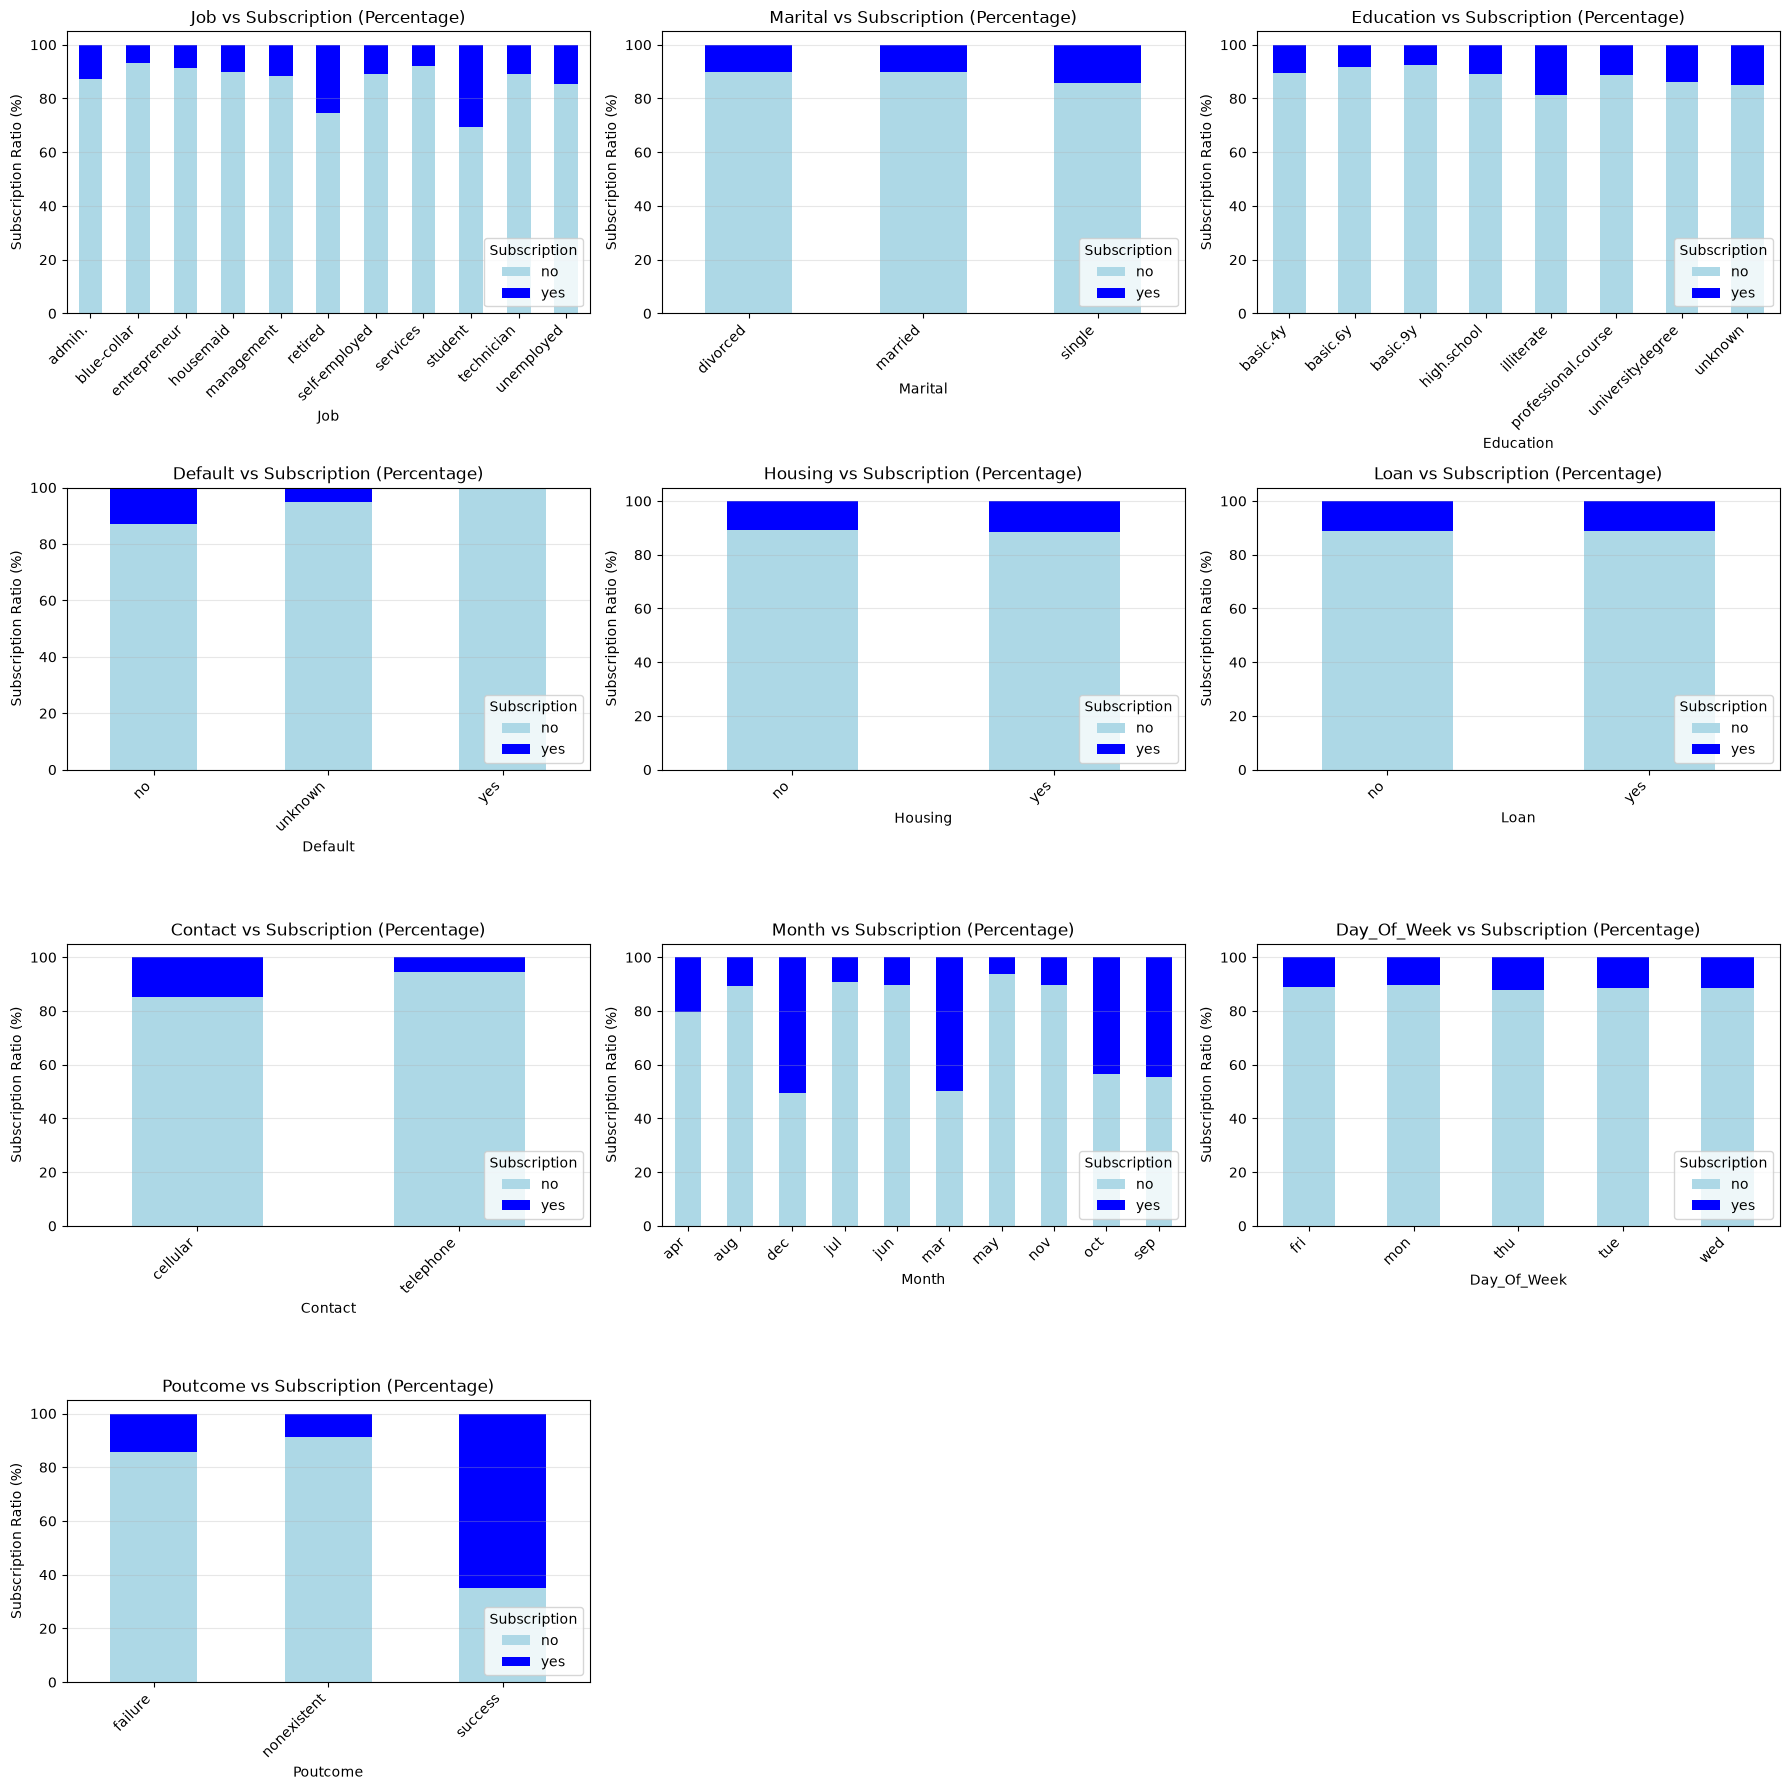

In [606]:
# Plot the categorical variables with stacked bar chart for Subscription ratio.

categorical_features = mode_impute_columns_df.drop(columns=['y']).select_dtypes(include=['object', 'string']).columns

fig, axes = plt.subplots(4, 3, figsize=(18, 18))
fig.subplots_adjust(hspace=0.6, wspace=0.6)
axes = axes.flatten()

palette = {'yes': 'blue', 'no': 'lightblue' }

for i, feature in enumerate(categorical_features):
    # If a category has no records for a target class, replace the empty value with 0.
    temp_df = mode_impute_columns_df.groupby([feature, 'y']).size().unstack().fillna(0)

    # Convert the counts into percentages within each category
    # Divide each 'yes' and 'no' count by the total count in the same category to calculate the subscription percentages.
    temp_df = temp_df.div(temp_df.sum(axis=1), axis=0)*100

    temp_df.plot(kind='bar', stacked=True, color=palette, ax=axes[i])
    axes[i].set_title(f'{feature.title()} vs Subscription (Percentage)')
    axes[i].set_ylabel('Subscription Ratio (%)')
    axes[i].set_xlabel(feature.title())
    axes[i].legend(title='Subscription', loc='lower right')
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45, ha='right')    
    axes[i].grid(axis='y', alpha=0.3)

# Remove unused subplot spaces
for j in range (i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

- Job:\
Students and Retired customers showed higher subscription rates than the other Job categories.\
However, these groups contained fewer customer counts than the largest Job categories indicating that the higher subscription rates were based on smaller sample sizes.
- Marital:\
Single customers showed the highest subscription rate among the marital categories. The count plot indicates that this observation was not driven by a small sample.
- Education:\
The illiterate category showed the highest subscription rate. However, this category contained only 16 customers, so the result was based on a very small sample. Apart from the illiterate category, customers with a high school, a professional course and a university degree showed slightly higher subscription rates than the basic education levels.
- Default:\
The default = yes category had no customer subscriptions. However, this category contained only 3 customers so no meaningful conclusion can be made. Among the remaining categories, customers with default = no showed a higher subscription rate than those with default = unknown.
- Housing:\
Customers with and without housing loans showed similar subscription rates of approximately 11% suggesting little association between housing loan status and subscription.
- Loan:\
Personal loan status showed the similar patterns with housing loan status. Customers with and without personal loans showed similar subscription rates of approximately 11%, suggesting little association between personal loan status and subscription.
- Contact:\
Customers contacted by cellular phone had higher subscription rates than those contacted by telephone.
- Month:\
Months with fewer customer contacts such as March, September, October, December showed relatively higher subscription rates than the months with larger customer counts.
- Day of Week:\
Subscription rates were similar across all days of the week suggesting little association between the day of contact and customer subscription.
- Poutcome:\
Although the number of customers with a previous successful campaign outcome was relatively small, this group showed the highest subscription rate. This suggests that customers who responded successfully to a previous marketing campaign were more likely to subscribe again.

### 7. Splitting data into X and y

7.1 Separate features and target\
Original dataset has already been split into 80% training dataframe and 20% testing dataframe.\
Now split training dataframe into X and y.\
Here, both training dataframe and testing dataframe will be split but the testing dataframe has not been processed at this stage therefore the number of columns is expected to be different.
- Training dataframe: clean_train_df
- Testing dataframe: test_df\
\
Duration column is dropped as the duration column cannot be used for the prediction (as noted above). 

In [607]:
# Split the training dataframe and testing dataframe into X_train and y_train, X_test and y_test
# Dropping duration colmn from both dataframes

# Split the training dataframe
X_train = clean_train_df.drop(columns=['y', 'duration'])
y_train = clean_train_df['y']

# Split the testing dataframe
X_test = test_df.drop(columns=['y', 'duration'])
y_test = test_df['y']

# check X_train and y_train, X_test and y_test
print('Training set:', X_train.shape, y_train.shape)
print("Testing set:", X_test.shape, y_test.shape)
print('\nX_train data:')
print(X_train.info())
print('\ny_train data:')
print(y_train.info())
print('\nX_test data:')
print(X_test.info())
print('\ny_test data:')
print(y_test.info())

Training set: (32950, 62) (32950,)
Testing set: (8238, 19) (8238,)

X_train data:
<class 'pandas.DataFrame'>
Index: 32950 entries, 25611 to 10747
Data columns (total 62 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   age                            32950 non-null  int64  
 1   campaign                       32950 non-null  int64  
 2   pdays                          32950 non-null  int64  
 3   previous                       32950 non-null  int64  
 4   emp.var.rate                   32950 non-null  float64
 5   cons.price.idx                 32950 non-null  float64
 6   cons.conf.idx                  32950 non-null  float64
 7   euribor3m                      32950 non-null  float64
 8   nr.employed                    32950 non-null  float64
 9   job_admin.                     32950 non-null  float64
 10  job_blue-collar                32950 non-null  float64
 11  job_entrepreneur               32950

In [608]:
# Copy the data sets
X_train = X_train.copy()
y_train = y_train.copy()
X_test = X_test.copy()
y_test = y_test.copy()

7.2 Convert target variable to binary\
\
The target variable 'y' was converted to binary values ('no' = 0, 'yes' = 1) using a mapping technique to simplify model training and evaluation.

In [609]:
# Copy the origianl y_train and y_test datasets before converting to binary.

y_train_before_conversion = y_train.copy()
y_test_before_conversion = y_test.copy()

In [610]:
# Convert target values to binary
# No subscription = 0
# Subscription = 1

y_train = y_train.map({'no': 0, 'yes': 1})
y_test = y_test.map({'no': 0, 'yes': 1})

In [611]:
# Check if the mapping worked

print('Before conversion:')
print(f'y_train:\n{y_train_before_conversion.value_counts()}')
print(f'y_test:\n{y_test_before_conversion.value_counts()}')

print('\nAfter conversion:')
print(f'y_train:\n{y_train.value_counts()}')
print(f'y_test:\n{y_test.value_counts()}')

Before conversion:
y_train:
y
no     29238
yes     3712
Name: count, dtype: int64
y_test:
y
no     7310
yes     928
Name: count, dtype: int64

After conversion:
y_train:
y
0    29238
1     3712
Name: count, dtype: int64
y_test:
y
0    7310
1     928
Name: count, dtype: int64


### 8. Apply the same impute method and OneHotEncoding method to testing data
Before feature scaling is applied, trainig and testing dataset need to be preprocessed to the same stage to avoid the complex workflow.\
Therefore, on testing data set, imputation and onehotencoding on categorical variables are applied with the same method used for training set earlier so that their data structures are the same.

8.1 Impute unknown values\
\
Imputation will be applied with the most frequent values for job, marital, housing and loan as same as train dataset.\
Simpleimputater with strategy='most_frequent' is applied for those 4 categories as below.
- job: admin.
- marital: married
- housing: yes
- loan: no

In [612]:
# Check if the unknown values are in the same columns as train_df
print('Unknown counts before replacing with Nan:')
(X_test == 'unknown').sum()

Unknown counts before replacing with Nan:


age                  0
job                 65
marital             15
education          334
default           1657
housing            194
loan               194
contact              0
month                0
day_of_week          0
campaign             0
pdays                0
previous             0
poutcome             0
emp.var.rate         0
cons.price.idx       0
cons.conf.idx        0
euribor3m            0
nr.employed          0
dtype: int64

In [613]:
# Copy X_test to compare before and after the imputation
X_test_before_imputation = X_test.copy()

In [614]:
# Replace 'unknown' with NaN for 'job', 'marital', 'housing', 'loan' columns as SimpleImputer picks the missing values
mode_impute_columns = ['job', 'marital', 'housing', 'loan']
for col in mode_impute_columns:
    X_test.loc[X_test[col] == 'unknown', col] = np.nan

# Compare the unknown counts before and after replacing with NaN

unknown_counts_before = (X_test_before_imputation == 'unknown').sum()
missing_counts_before = X_test_before_imputation.isnull().sum()
unknown_counts_after = (X_test == 'unknown').sum()
missing_counts_after = X_test.isnull().sum()

impute_summary_df = pd.DataFrame({
    'Unknown counts before replacing': unknown_counts_before,
    'Missing counts before replacing': missing_counts_before,
    'Unknown counts after replacing': unknown_counts_after,
    'Missing counts after replacing': missing_counts_after,
})

display(impute_summary_df)

,Unknown counts before replacing,Missing counts before replacing,Unknown counts after replacing,Missing counts after replacing
age,0,0,0,0
job,65,0,0,65
marital,15,0,0,15
education,334,0,334,0
default,1657,0,1657,0
housing,194,0,0,194
loan,194,0,0,194
contact,0,0,0,0
month,0,0,0,0
day_of_week,0,0,0,0


In [615]:
# Imputation for missing values with mode method
# Reuse the fitted imputer from X_train (do not create a new SimpleImputer).
# Do NOT create a new SimpleImputer or use fit_transform() on the test data.
# The test data must use the same imputation values learned from the training data and use transform()
X_test[mode_impute_columns] = mode_imputer.transform(X_test[mode_impute_columns])

missing_values_before = X_test_before_imputation.isnull().sum()
missing_values_after = X_test.isnull().sum()

Imputation_summary_df = pd.DataFrame({
    'before imputation': missing_values_before,
    'after imputation': missing_values_after
})

print('Dataframe after imputed:')
display(X_test)

Dataframe after imputed:


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
14455,32,management,divorced,university.degree,no,no,no,cellular,jul,tue,5,999,0,nonexistent,1.4,93.918,-42.7,4.961,5228.1
36380,37,unemployed,married,university.degree,no,no,no,cellular,jun,tue,1,999,0,nonexistent,-2.9,92.963,-40.8,1.262,5076.2
40076,73,retired,divorced,professional.course,unknown,yes,no,cellular,jul,thu,2,999,0,nonexistent,-1.7,94.215,-40.3,0.810,4991.6
10778,44,entrepreneur,married,basic.4y,unknown,no,no,telephone,jun,tue,2,999,0,nonexistent,1.4,94.465,-41.8,4.961,5228.1
27939,28,admin.,single,high.school,no,no,no,cellular,mar,fri,2,999,0,nonexistent,-1.8,92.843,-50.0,1.531,5099.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33359,48,management,married,basic.9y,no,yes,no,cellular,may,tue,1,999,0,nonexistent,-1.8,92.893,-46.2,1.291,5099.1
34998,30,services,single,high.school,no,yes,no,cellular,may,fri,1,999,0,nonexistent,-1.8,92.893,-46.2,1.250,5099.1
39861,33,services,married,high.school,no,no,no,cellular,jun,mon,1,999,1,failure,-1.7,94.055,-39.8,0.720,4991.6
3920,44,blue-collar,married,basic.6y,no,yes,yes,telephone,may,mon,7,999,0,nonexistent,1.1,93.994,-36.4,4.858,5191.0


8.2 Apply Encoder on test dataset\
The same method used for training dataset applied on test dataset.\
OneHotEncoding is applied to convert categorical variables into binary columns.

In [616]:
# Apply OneHotEncoder on test dataset
# Reuse the fitted encoder from X_train (do not create a new encoder).
# Do NOT create a new encoder or use fit_transform() on the test data.
# The test data must use the same encoder learned from the training data and use transform()
categorical_columns = X_test.select_dtypes(include=['object', 'string']).columns

encoded_data = encoder.transform(X_test[categorical_columns])

test_encoded_df = pd.DataFrame(
    encoded_data,
    columns=encoder.get_feature_names_out(categorical_columns)
)

print('Compare test_encoded_df and encoded_df to make sure testing and training dataset has the same columns')
print(f'Training dataset: {encoded_df.shape}')
print(f'Testing dataset: {test_encoded_df.shape}')

print('Dataframe after OneHotEncoder applied:')
display(test_encoded_df.head())

display(test_encoded_df.info())


Compare test_encoded_df and encoded_df to make sure testing and training dataset has the same columns
Training dataset: (32950, 53)
Testing dataset: (8238, 53)
Dataframe after OneHotEncoder applied:


,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,...,month_oct,month_sep,day_of_week_fri,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_failure,poutcome_nonexistent,poutcome_success
0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


<class 'pandas.DataFrame'>
RangeIndex: 8238 entries, 0 to 8237
Data columns (total 53 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   job_admin.                     8238 non-null   float64
 1   job_blue-collar                8238 non-null   float64
 2   job_entrepreneur               8238 non-null   float64
 3   job_housemaid                  8238 non-null   float64
 4   job_management                 8238 non-null   float64
 5   job_retired                    8238 non-null   float64
 6   job_self-employed              8238 non-null   float64
 7   job_services                   8238 non-null   float64
 8   job_student                    8238 non-null   float64
 9   job_technician                 8238 non-null   float64
 10  job_unemployed                 8238 non-null   float64
 11  job_unknown                    8238 non-null   float64
 12  marital_divorced               8238 non-null   float64
 13 

None

Put X_test and test_encoded_df into one dataset to make the final X_test dataset after preprocessing data.

In [617]:
# Check X_test and test_encoded_df have the same number of rows
print(f'Rows count for X_test: {len(X_test.drop(columns=categorical_columns))}')
print(f'Rows count for test_encoded_df: {len(test_encoded_df)}')

Rows count for X_test: 8238
Rows count for test_encoded_df: 8238


In [618]:
# concat X_test and test_encoded_df
test_encoded_df.index=X_test.index
X_test = pd.concat(
    [X_test.drop(columns=categorical_columns), test_encoded_df], axis=1
)

print(f'Rows count for X_test: {len(X_test)}\n')

print('X_test with one-hot encoded data:')
display(X_test)

# Check if there is any missing values in X_test dataset
if X_test.isnull().sum().sum() > 0:
    print(X_test[X_test.isnull().any(axis=1)])
else:
    print('No missing values in X_test dataset')

Rows count for X_test: 8238

X_test with one-hot encoded data:


,age,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,job_admin.,...,month_oct,month_sep,day_of_week_fri,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_failure,poutcome_nonexistent,poutcome_success
14455,32,5,999,0,1.4,93.918,-42.7,4.961,5228.1,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
36380,37,1,999,0,-2.9,92.963,-40.8,1.262,5076.2,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
40076,73,2,999,0,-1.7,94.215,-40.3,0.810,4991.6,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
10778,44,2,999,0,1.4,94.465,-41.8,4.961,5228.1,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
27939,28,2,999,0,-1.8,92.843,-50.0,1.531,5099.1,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33359,48,1,999,0,-1.8,92.893,-46.2,1.291,5099.1,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
34998,30,1,999,0,-1.8,92.893,-46.2,1.250,5099.1,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
39861,33,1,999,1,-1.7,94.055,-39.8,0.720,4991.6,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
3920,44,7,999,0,1.1,93.994,-36.4,4.858,5191.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


No missing values in X_test dataset


In [619]:
# Final check before feature scaling.
# Check the number of columns are the same in training and testing dataset.
# Training and testing datasets have the same features and column order.
print(f'Trainig dataset: {X_train.shape}')
print(f'Testing dataset: {X_test.shape}')
print(f'Training and Testing datasets have the same columns: {X_train.columns.equals(X_test.columns)}')

Trainig dataset: (32950, 62)
Testing dataset: (8238, 62)
Training and Testing datasets have the same columns: True


### 9. Feature Engineering

The further analysis on numerical variables showed that pdays was highly concentrated at 999. In this dataset, 999 indicates that the customer had not been contacted in a previous campaign rather than representing an actual number of days.\
Further analysis is performed before feature engineering performed.

In [620]:
# Check the distribution of pdays values.
# value_counts() counts each unique pdays value.
# sort_index() sorts the results by the pdays values instead of by their counts.
print('Distribution of pdays:')
display(X_train['pdays'].value_counts().sort_index(ascending=False))

# Calculate the proportaion of 999 values and the total of other values
print('\nProportion of pdays values:')

proportion_999 = (((X_train['pdays'] == 999).sum())/(len(X_train)))*100
proportion_not_999 = (((X_train['pdays'] != 999).sum())/(len(X_train)))*100

print(f'Customers with pdays = 999 (not previously contacted): {proportion_999:.0f}%')
print(f'Customers with pdays < 999 (previously contacted): {proportion_not_999:.0f}%')

Distribution of pdays:


pdays
999    31724
27         1
26         1
25         1
22         3
21         2
20         1
19         2
18         6
17         8
16         9
15        21
14        18
13        28
12        40
11        21
10        43
9         45
8         14
7         47
6        337
5         40
4         97
3        355
2         52
1         22
0         12
Name: count, dtype: int64


Proportion of pdays values:
Customers with pdays = 999 (not previously contacted): 96%
Customers with pdays < 999 (previously contacted): 4%


The pdays variable was highly concentrated at the value 999, with 96% of customers having this value. Since 999 indicates that a customer was not contacted in a previous marketing campaign rather than representing the actual number of days since the last contact, pdays was converted into a binary feature (pcontacted). Furthermore, the analysis of the poutcome variable showed that customers who had responded successfully to a previous marketing campaign were more likely to subscribe to a term deposit. Representing pdays as a binary feature better reflects the underlying meaning of the variable and may provide more useful information for model training. The new feature, pcontacted, will be converted into 1 for customers who had been contacted previously and 0 for customers who had not been contacted previously. The original pdays variable will be removed.

In [621]:
# copy the original datasets
X_train_before_feature_scaling = X_train.copy()
X_test_before_feature_scaling = X_test.copy()

In [622]:
# Check if the code works
# (X_train['pdays'] != 999).astype(int)

In [623]:
# Comparing with binary data and original data
# X_train['pdays']

In [624]:
# Convert pdays into binary feature under new column name 'pcontacted' meaining previously contacted
# This applies on both X_train and X_test.

# pdays != 999 returns True (previously contacted) or False (previously Not contacted) 
# then astype(int) converts the data type True to 1 and False to 0.
X_train['pcontacted'] = (X_train['pdays'] != 999).astype(int)
X_test['pcontacted'] = (X_test['pdays'] != 999).astype(int)

# Remove pdays column
X_train.drop(columns='pdays', inplace=True)
X_test.drop(columns='pdays', inplace=True)

display(X_train)
display(X_test)


,age,campaign,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,job_admin.,job_blue-collar,...,month_sep,day_of_week_fri,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_failure,poutcome_nonexistent,poutcome_success,pcontacted
25611,49,4,0,-0.1,93.200,-42.0,4.120,5195.8,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0
26010,37,2,1,-0.1,93.200,-42.0,4.120,5195.8,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0
40194,78,1,0,-1.7,94.215,-40.3,0.870,4991.6,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0
297,36,2,0,1.1,93.994,-36.4,4.857,5191.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0
36344,59,2,0,-2.9,92.963,-40.8,1.262,5076.2,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40205,28,1,0,-1.7,94.215,-40.3,0.876,4991.6,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0
27316,52,1,1,-0.1,93.200,-42.0,4.021,5195.8,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0
14392,54,4,0,1.4,93.918,-42.7,4.962,5228.1,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0
7494,29,1,0,1.1,93.994,-36.4,4.864,5191.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0


,age,campaign,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,job_admin.,job_blue-collar,...,month_sep,day_of_week_fri,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_failure,poutcome_nonexistent,poutcome_success,pcontacted
14455,32,5,0,1.4,93.918,-42.7,4.961,5228.1,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0
36380,37,1,0,-2.9,92.963,-40.8,1.262,5076.2,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0
40076,73,2,0,-1.7,94.215,-40.3,0.810,4991.6,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0
10778,44,2,0,1.4,94.465,-41.8,4.961,5228.1,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0
27939,28,2,0,-1.8,92.843,-50.0,1.531,5099.1,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33359,48,1,0,-1.8,92.893,-46.2,1.291,5099.1,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0
34998,30,1,0,-1.8,92.893,-46.2,1.250,5099.1,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0
39861,33,1,1,-1.7,94.055,-39.8,0.720,4991.6,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0
3920,44,7,0,1.1,93.994,-36.4,4.858,5191.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0


In [625]:
# Check that the proportion of customers remains the same
# after converting pdays into the binary feature pcontacted.
not_previously_contacted = (((X_train['pcontacted'] == 0).sum())/(len(X_train)))*100
previously_contacted = (((X_train['pcontacted'] == 1).sum())/(len(X_train)))*100

print(f'Customers not previously contacted: {not_previously_contacted:.0f}%')
print(f'Customers previously contacted: {previously_contacted:.0f}%')

Customers not previously contacted: 96%
Customers previously contacted: 4%


### 10. Feature scaling

From the further analysis on the numerical variables, RobustScaleral was selected as some numerical variables contained outliers and all observations were retained because they represented valid values.\
RobustScaler uses the median and the interquartile range (IQR) and is less sensitive to outliers and\
it reduces the influence of extreme values during the model training.  

In [626]:
# Create the copy of X_train, X_test
X_train_before_scaling = X_train.copy()
X_test_before_scaling = X_test.copy()

In [627]:
# Create numerical feature list with the original numerical columns (pdays not longer exist in the dataset after feature engineering)
numerical_features = X_train.columns[0:8].to_list()
print(numerical_features)

['age', 'campaign', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']


In [628]:
# Create the scaler
scaler = RobustScaler()

# Scale the training data
X_train[numerical_features] = scaler.fit_transform(X_train[numerical_features])

# Scale the testing data
X_test[numerical_features] = scaler.transform(X_test[numerical_features])

In [629]:
# Compare the dataset before after the scaling: Fisrt five rows of the dataset

print('Before scaling:')
display(X_train_before_scaling.head())
print('\nAfter scaling:')
display(X_test.head())

Before scaling:


,age,campaign,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,job_admin.,job_blue-collar,...,month_sep,day_of_week_fri,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_failure,poutcome_nonexistent,poutcome_success,pcontacted
25611,49,4,0,-0.1,93.200,-42.0,4.120,5195.8,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0
26010,37,2,1,-0.1,93.200,-42.0,4.120,5195.8,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0
40194,78,1,0,-1.7,94.215,-40.3,0.870,4991.6,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0
297,36,2,0,1.1,93.994,-36.4,4.857,5191.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0
36344,59,2,0,-2.9,92.963,-40.8,1.262,5076.2,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0



After scaling:


,age,campaign,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,job_admin.,job_blue-collar,...,month_sep,day_of_week_fri,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_failure,poutcome_nonexistent,poutcome_success,pcontacted
14455,-0.400000,1.5,0.0,0.09375,0.183896,-0.142857,0.028753,0.287597,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0
36380,-0.066667,-0.5,0.0,-1.25000,-0.855277,0.158730,-0.993918,-0.889922,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0
40076,2.333333,0.0,0.0,-0.87500,0.507073,0.238095,-1.118883,-1.545736,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0
10778,0.400000,0.0,0.0,0.09375,0.779108,0.000000,0.028753,0.287597,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0
27939,-0.666667,0.0,0.0,-0.90625,-0.985854,-1.301587,-0.919547,-0.712403,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0


In [630]:
# Compare the dataset before after the scaling: statistical summary

print('Statistical Summary before scaling:')
display(X_train_before_scaling.describe().round(2))
print('\nStatistical Summary after scaling:')
display(X_test.describe().round(2))

Statistical Summary before scaling:


,age,campaign,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,job_admin.,job_blue-collar,...,month_sep,day_of_week_fri,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_failure,poutcome_nonexistent,poutcome_success,pcontacted
count,32950.00,32950.00,32950.00,32950.00,32950.00,32950.00,32950.00,32950.00,32950.00,32950.00,...,32950.00,32950.00,32950.00,32950.00,32950.0,32950.0,32950.00,32950.00,32950.00,32950.00
mean,40.01,2.56,0.17,0.08,93.58,-40.51,3.62,5166.90,0.25,0.23,...,0.01,0.19,0.21,0.21,0.2,0.2,0.10,0.86,0.03,0.04
std,10.40,2.75,0.50,1.57,0.58,4.63,1.74,72.43,0.43,0.42,...,0.12,0.39,0.40,0.41,0.4,0.4,0.31,0.34,0.18,0.19
min,17.00,1.00,0.00,-3.40,92.20,-50.80,0.63,4963.60,0.00,0.00,...,0.00,0.00,0.00,0.00,0.0,0.0,0.00,0.00,0.00,0.00
25%,32.00,1.00,0.00,-1.80,93.08,-42.70,1.34,5099.10,0.00,0.00,...,0.00,0.00,0.00,0.00,0.0,0.0,0.00,1.00,0.00,0.00
50%,38.00,2.00,0.00,1.10,93.75,-41.80,4.86,5191.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.0,0.0,0.00,1.00,0.00,0.00
75%,47.00,3.00,0.00,1.40,93.99,-36.40,4.96,5228.10,1.00,0.00,...,0.00,0.00,0.00,0.00,0.0,0.0,0.00,1.00,0.00,0.00
max,98.00,56.00,7.00,1.40,94.77,-26.90,5.04,5228.10,1.00,1.00,...,1.00,1.00,1.00,1.00,1.0,1.0,1.00,1.00,1.00,1.00



Statistical Summary after scaling:


,age,campaign,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,job_admin.,job_blue-collar,...,month_sep,day_of_week_fri,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_failure,poutcome_nonexistent,poutcome_success,pcontacted
count,8238.00,8238.00,8238.00,8238.00,8238.00,8238.00,8238.00,8238.00,8238.00,8238.00,...,8238.00,8238.00,8238.00,8238.00,8238.0,8238.0,8238.0,8238.00,8238.00,8238.00
mean,0.14,0.30,0.17,-0.32,-0.19,0.21,-0.34,-0.18,0.26,0.22,...,0.01,0.18,0.21,0.21,0.2,0.2,0.1,0.87,0.03,0.04
std,0.70,1.42,0.48,0.49,0.63,0.73,0.48,0.55,0.44,0.41,...,0.11,0.39,0.40,0.41,0.4,0.4,0.3,0.34,0.18,0.18
min,-1.40,-0.50,0.00,-1.41,-1.68,-1.43,-1.17,-1.76,0.00,0.00,...,0.00,0.00,0.00,0.00,0.0,0.0,0.0,0.00,0.00,0.00
25%,-0.40,-0.50,0.00,-0.91,-0.73,-0.14,-0.97,-0.71,0.00,0.00,...,0.00,0.00,0.00,0.00,0.0,0.0,0.0,1.00,0.00,0.00
50%,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.0,0.0,0.0,1.00,0.00,0.00
75%,0.60,0.50,0.00,0.09,0.27,0.86,0.03,0.29,1.00,0.00,...,0.00,0.00,0.00,0.00,0.0,0.0,0.0,1.00,0.00,0.00
max,4.00,19.50,5.00,0.09,1.11,2.37,0.04,0.29,1.00,1.00,...,1.00,1.00,1.00,1.00,1.0,1.0,1.0,1.00,1.00,1.00


Age and Campaign Boxplots Before Scaling:


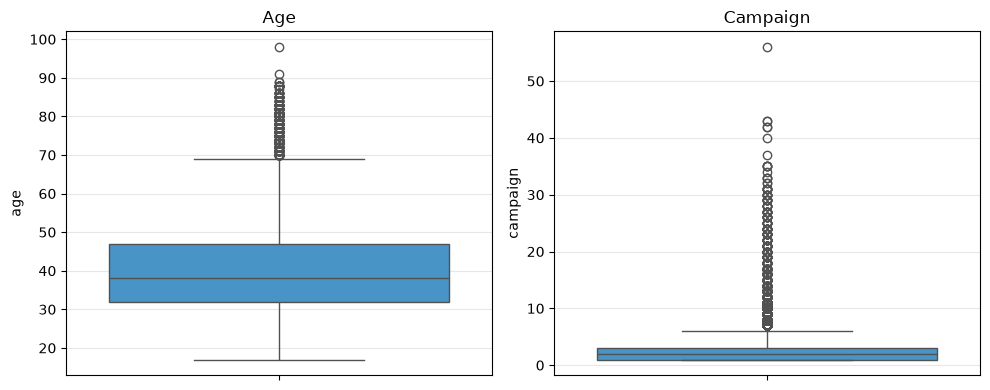

Age and Campaign Boxplots After Scaling:


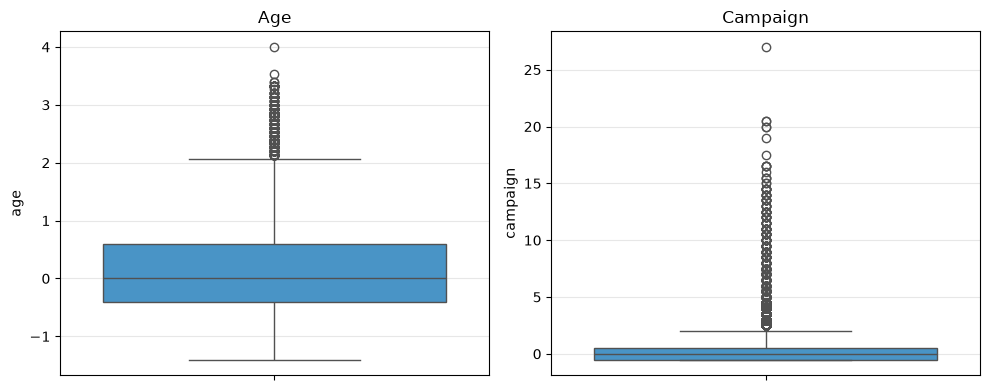

In [631]:
# Compare before and after scaling for the columns which had outliers with boxplots.

age_campaign = ['age', 'campaign']

print('Age and Campaign Boxplots Before Scaling:')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for i, variable in enumerate(age_campaign):
    sns.boxplot(y=X_train_before_scaling[variable], ax=axes[i], color='#3498DB')
    axes[i].set_title(variable.replace('.', ' ').title())
    axes[i].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print('Age and Campaign Boxplots After Scaling:')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for i, variable in enumerate(age_campaign):
    sns.boxplot(y=X_train[variable], ax=axes[i], color='#3498DB')
    axes[i].set_title(variable.replace('.', ' ').title())
    axes[i].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### 11. Model experimentation

The three models were selected for model experimentation:
- Logistic Regression:\
The model was selected because it is a simple and interpretable classification algorithm suitable for predicting a binary outcome.
- Support Vector Machine (SVM):\
SVM was selected because it is suitable for classification with multiple features. It finds an optimal decision boundary (hyperplane) that separates data points into different classes while maximising the margin between the closest points of each class. SVC will be used as the classification implementation of SVM.
- Random Forest:\
The model was selected because it can capture non-linear relationships and interactions between features by combining multiple decision trees.

11.1 Train baseline models with imbalanced training dataset\
\
As mentioned in the EDA section, the target was imbalanced with approximately 89% of customers not subscribing to a term deposit and 11% subscribing.\
Train the baseline models on the original imbalanced training data before tuning hyperparameters.\
Evaluate the baseline models using 5-fold cross-validation on the training data, keeping the test dataset untouched for the final model evaluation.

11.1.1 Baseline Logistic Regression model

In [632]:
# Create baseline Logistic Regression model
# Increase max_iter from the default 100 to 1000 to allow sufficient iterations for convergence
baseline_log_reg = LogisticRegression(
    max_iter=1000,
    random_state=42
)
# Fit it to the training data
baseline_log_reg.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [633]:
# Evaluate the baseline model using 5-fold cross-validation on the training data
# to keep the test dataset untouched for final model evaluation

# For classification, cv=5 uses StratifiedKFold by default,
# which approximately preserves the 89%/11% target class distribution in each fold

# Use F1 score because the target is imbalanced and F1 balances precision and recall

baseline_log_reg_cv = cross_val_score(
    baseline_log_reg,
    X_train,
    y_train,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=2
)

print(baseline_log_reg_cv)
print(f'Mean CV F1 score: {baseline_log_reg_cv.mean():.3f}')

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.


[0.35294118 0.34441088 0.31621349 0.32329317 0.34131737]
Mean CV F1 score: 0.336


[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:   13.1s remaining:   19.8s
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:   13.2s finished


11.1.2 Baseline Support Vector Classifier (SVC) model

In [634]:
# Create baseline SVC model
baseline_svc = SVC(
    random_state=42
)
# Fit it to the training data
baseline_svc.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None


In [635]:
# Evaluate the baseline model using 5-fold cross-validation on the training data
baseline_svc_cv = cross_val_score(
    baseline_svc,
    X_train,
    y_train,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=2
)

print(baseline_svc_cv)
print(f'Mean CV F1 score: {baseline_svc_cv.mean():.3f}')

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:  2.3min remaining:  3.5min


[0.30640084 0.34530938 0.29454171 0.32610939 0.33265306]
Mean CV F1 score: 0.321


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:  2.5min finished


11.1.3 Baseline Random Forest

In [636]:
# Create baseline Random Forest model
baseline_rf = RandomForestClassifier(
    random_state=42
)
# Fit it to the training data
baseline_rf.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [637]:
# Evaluate the baseline model using 5-fold cross-validation on the training data
baseline_rf_cv = cross_val_score(
    baseline_rf,
    X_train,
    y_train,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=2
)

print(baseline_rf_cv)
print(f'Mean CV F1 score: {baseline_rf_cv.mean():.3f}')

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:    5.3s remaining:    8.1s
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    5.4s finished


[0.36298293 0.35262206 0.35708004 0.35638298 0.36316695]
Mean CV F1 score: 0.358


11.2 Baseline model comparison\
\
Compare the mean cross-validation F1 scores of the three baseline models to assess their performance on the original imbalanced training data.

In [638]:
# Compare baseline models
baseline_model_comparison = pd.DataFrame({
    'model': [
        'Logistic Regression',
        'SVC',
        'Random Forest'
    ],
    'mean_cv_f1_score': [
        baseline_log_reg_cv.mean(),
        baseline_svc_cv.mean(),
        baseline_rf_cv.mean()
    ]
})

baseline_model_comparison['mean_cv_f1_score'] = (
    baseline_model_comparison['mean_cv_f1_score'].round(3)
)

display(baseline_model_comparison)

,model,mean_cv_f1_score
0,Logistic Regression,0.336
1,SVC,0.321
2,Random Forest,0.358


Baseline models comparison summary\
\
Random Forest achieved the highest mean CV F1 score of 0.358 among the baseline models.

### 12. Hyperparameter tuning

The baseline models showed relatively low F1 scores in predicting customers who subscribe to a term deposit.\
The models were trained using the original imbalanced training data with default model parameters.\
\
In this section, GridSearchCV will be used to tune the hyperparameters for each model.\
5-fold cross-validation will be used to evaluate each parameter combination with F1 score selected as the scoring metric.\
\
GridSearchCV + 5-fold cross-validation
- Logistic Regression
- SVC
- Random Forest\
\

As the target variable is imbalanced, class_weight='balanced' will also be tested against the default class weight.\
F1 score was selected because it balances precision and recall and is more appropriate than accuracy alone for evaluating performance on the minority class.

12.1.1 Tune Logistic Regression model\
Test different values of C and class_weight to identify the parameter combination with the highest mean cross-validation F1 score.

In [639]:
# Logistic regression parameter grid

# C controls the strength of regularisation:
# smaller C = stronger regularisation, larger C = weaker regularisation
# class_weight tests the default weighting against balancing the imbalanced classes

log_reg_param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'class_weight': [None, 'balanced']
}

In [640]:
# Create GridSearchCV to test all parameter combinations
# using 5-fold cross-validation and f1 score for evaluation

grid_log_reg = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    log_reg_param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=2
)

In [641]:
# Fit GridSearchCV to the training data
grid_log_reg.fit(X_train, y_train)

Fitting 5 folds for each of 8 candidates, totalling 40 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.01, 0.1, ...], 'class_weight': [None, 'balanced']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to desi

In [642]:
# Find the best Logistic Regression model selected by GridSearchCV
best_log_reg = grid_log_reg.best_estimator_

# Find the best parameters
best_param_log_reg = grid_log_reg.best_params_

# Find the mean F1 score from the cross-validation for the best parameter combination
best_f1_log_reg = grid_log_reg.best_score_


print(f'Best model selection:{best_log_reg}')
print(f'Best parameters: {best_param_log_reg}')
print(f'Best Cross-validation F1 score: {best_f1_log_reg:.3f}')

Best model selection:LogisticRegression(C=10, class_weight='balanced', max_iter=1000,
                   random_state=42)
Best parameters: {'C': 10, 'class_weight': 'balanced'}
Best Cross-validation F1 score: 0.451


12.1.2 Refine Logistic Regression hyperparameter tuning\
\
Initial tuning showed C=10 as the best selection which was weakest regularisation among the values tested.\
Based on this result, perform further tuning with C=10 and C=100 to investigate whether weaker regularisation\
could improve model performance while retaining class_weight=’balanced'.

In [643]:
# C=10 was the highest value tested and selected in the initial GridSearchCV,
# so C=100 is tested to investigate whether weaker regularisation improves F1 score

refined_log_reg_param_grid = {
    'C': [10, 100],
    'class_weight': ['balanced']
}

In [644]:
# Create GridSearchCV to test refined Logistic Regression parameters
# using 5-fold cross-validation and F1 score for evaluation

refined_grid_log_reg = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    refined_log_reg_param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=2
)

In [645]:
# Fit refined GridSearchCV to the training data
refined_grid_log_reg.fit(X_train, y_train)

Fitting 5 folds for each of 2 candidates, totalling 10 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [10, 100], 'class_weight': ['balanced']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom s

In [646]:
# Find the best Logistic Regression model selected by the refined GridSearchCV
refined_best_log_reg = refined_grid_log_reg.best_estimator_

# Find the best parameters
refined_best_param_log_reg = refined_grid_log_reg.best_params_

# Find the mean F1 score from the cross-validation for the best parameter combination
refined_best_f1_log_reg = refined_grid_log_reg.best_score_


print(f'Best model selection: {refined_best_log_reg}')
print(f'Best parameters: {refined_best_param_log_reg}')
print(f'Best Cross-validation F1 score: {refined_best_f1_log_reg:.3f}')

Best model selection: LogisticRegression(C=10, class_weight='balanced', max_iter=1000,
                   random_state=42)
Best parameters: {'C': 10, 'class_weight': 'balanced'}
Best Cross-validation F1 score: 0.451


Conclusion:\
The refined tuning retained C=10 and class_weight='balanced'. Therefore, the parameters from the initial tuning were retained and no further evaluation of the refined model was required.

12.2 Tune Support Vector Classifiner model\
\
Linear and RBF kernels were selected to compare linear and non-linear decision boundaries while keeping the hyperparameter search computationally manageable.

Limitation:\
Hyperparameter tuning with GridSearchCV was attempted to test a range of parameter values.\
However, the process was not computationally feasible to complete in either VS Code or Google Colab.\
Therefore, selected parameters will be tested manually in the next section.

The attempted code is commented out to show what was attempted.

In [647]:
# # SVC parameter grid
# svc_param_grid = {
#     'C': [0.01, 0.1, 1, 10],
#     'kernel': ['linear', 'rbf'],
#     'class_weight': [None, 'balanced']
# }

In [648]:
# # Create GridSearchCV to test all parameter combinations
# # using 5-fold cross-validation and F1 score for evaluation

# grid_svc = GridSearchCV(
#     SVC(random_state=42),
#     svc_param_grid,
#     cv=5,
#     scoring='f1',
#     n_jobs=-1,
#     verbose=2
# )

In [649]:
# Fit GridSearchCV to the training data
# grid_svc.fit(X_train, y_train)

12.2.2 Manual tuning SVC\
\
As mentioned above, perform manual tuning with the parameters below
- Manual tuning 1: class_weight='balanced' and kernel='rbf'
- Manual tuning 2: class_weight='balanced' and kernel='linear'\
For both manual tuning experiments, the C value will be kept at its default value.


Manual tuning 1\
Parameter selection:
- class_weight='balanced'
- kernel='rbf'

In [650]:
# Create manual tuning 1 SVC model
manual_tuning1_svc = SVC(
    kernel='rbf',
    class_weight='balanced',
    random_state=42
)
# Fit it to the training data
manual_tuning1_svc.fit(X_train, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200


In [651]:
# Evaluate the manual tuning 1 SVC using 5-fold cross-validation on the training data
manual_tuning1_svc_cv = cross_val_score(
    manual_tuning1_svc,
    X_train,
    y_train,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=2
)

print(manual_tuning1_svc_cv)
print(f'Mean CV F1 score: {manual_tuning1_svc_cv.mean():.3f}')

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:  2.2min remaining:  3.3min


[0.49402823 0.46511628 0.45884072 0.4612987  0.46257099]
Mean CV F1 score: 0.468


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:  2.4min finished


Manual tuning 2\
Parameter selection:
- class_weight='balanced'
- kernel='linear'

In [652]:
# Create manual tuning 2 SVC model
manual_tuning2_svc = SVC(
    kernel='linear',
    class_weight='balanced',
    random_state=42
)
# Fit it to the training data
manual_tuning2_svc.fit(X_train, y_train)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200


In [653]:
# Evaluate the manual tuning 2 SVC using 5-fold cross-validation on the training data
manual_tuning2_svc_cv = cross_val_score(
    manual_tuning2_svc,
    X_train,
    y_train,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=2
)

print(manual_tuning2_svc_cv)
print(f'Mean CV F1 score: {manual_tuning2_svc_cv.mean():.3f}')

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:  5.1min remaining:  7.7min


[0.46513995 0.44559585 0.45338567 0.44794312 0.44773176]
Mean CV F1 score: 0.452


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:  5.3min finished


12.2.3 Compare Manual Tuning 1 (RBF) and Manual Tuning 2 (Linear)

In [654]:
# Compare manually tuned SVC models

svc_tuning_comparison = pd.DataFrame({
    'model': [
        'Manual tuning 1 SVC (RBF)',
        'Manual tuning 2 SVC (Linear)'
    ],
    'mean_cv_f1_score': [
        manual_tuning1_svc_cv.mean(),
        manual_tuning2_svc_cv.mean()
    ]
})

svc_tuning_comparison['mean_cv_f1_score'] = (
    svc_tuning_comparison['mean_cv_f1_score'].round(3)
)

display(svc_tuning_comparison)

,model,mean_cv_f1_score
0,Manual tuning 1 SVC (RBF),0.468
1,Manual tuning 2 SVC (Linear),0.452


Conclusion:\
Manual tuning 1 with kernel='rbf' achieved the higher mean CV F1 score of 0.468. Therefore, Manual tuning 1 was selected as the tuned SVC model.

12.3 Tune Random Forest

In [655]:
# Random Forest parameter grid
rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],    # This determines the minimum number of samples a node needs before the tree is allowed to split it further.
    'class_weight': [None, 'balanced']
}

In [656]:
# Create GridSearchCV to test all parameter combinations
# using 5-fold cross-validation and F1 score for evaluation

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=2
)

In [657]:
# Fit GridSearchCV to the training data
grid_rf.fit(X_train, y_train)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'class_weight': [None, 'balanced'], 'max_depth': [None, 10, ...], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_exampl

In [658]:
# Find the best Random Forest model selected by GridSearchCV
best_rf = grid_rf.best_estimator_

# Find the best parameters
best_param_rf = grid_rf.best_params_

# Find the mean F1 score from the cross-validation for the best param combination
best_f1_rf = grid_rf.best_score_


print(f'Best model selection:{best_rf}')
print(f'Best parameters: {best_param_rf}')
print(f'Best Cross-validation F1 score: {best_f1_rf:.3f}')

Best model selection:RandomForestClassifier(class_weight='balanced', max_depth=20,
                       min_samples_split=5, n_estimators=200, random_state=42)
Best parameters: {'class_weight': 'balanced', 'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 200}
Best Cross-validation F1 score: 0.480


In [659]:
# View the top Random Forest parameter combinations to see if the majority of top has the upper values

rf_cv_results = pd.DataFrame(grid_rf.cv_results_)

with pd.option_context('display.max_colwidth', None):
    display(
        rf_cv_results[
        ['params', 'mean_test_score','std_test_score', 'rank_test_score']
    ].sort_values('rank_test_score').head(10)
)

,params,mean_test_score,std_test_score,rank_test_score
23,"{'class_weight': 'balanced', 'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 200}",0.480326,0.013566,1
22,"{'class_weight': 'balanced', 'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 100}",0.478148,0.012810,2
18,"{'class_weight': 'balanced', 'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}",0.474406,0.012861,3
16,"{'class_weight': 'balanced', 'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}",0.474269,0.013142,4
17,"{'class_weight': 'balanced', 'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}",0.473757,0.013713,5
19,"{'class_weight': 'balanced', 'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}",0.473626,0.012329,6
15,"{'class_weight': 'balanced', 'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}",0.467601,0.012390,7
14,"{'class_weight': 'balanced', 'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}",0.467448,0.010989,8
21,"{'class_weight': 'balanced', 'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200}",0.464894,0.013426,9
20,"{'class_weight': 'balanced', 'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 100}",0.462354,0.012467,10


12.3.2 Refine Random Forest hyperparameter tuning\ 

The initial tuning showed that n_estimators=200, max_depth=20 and min_samples_split=5 which were at the upper end of the tested values. Therefore, further tuning will be performed to investigate whether increasing these values improves model performance.

In [660]:
# Refine Random Forest parameter grid
refined_rf_param_grid = {
    'n_estimators': [200, 300],
    'max_depth': [20, 30],
    'min_samples_split': [5, 10],
    'class_weight': ['balanced']
}

In [661]:
# Create refined GridSearchCV to test all parameter combinations
# using 5-fold cross-validation and F1 score for evaluation

refined_grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    refined_rf_param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=2
)

In [662]:
# Fit refined GridSearchCV to the training data
refined_grid_rf.fit(X_train, y_train)

Fitting 5 folds for each of 8 candidates, totalling 40 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'class_weight': ['balanced'], 'max_depth': [20, 30], 'min_samples_split': [5, 10], 'n_estimators': [200, 300]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_sel

In [663]:
# Find the best Random Forest model selected by the refined GridSearchCV
refined_best_rf = refined_grid_rf.best_estimator_

# Find the best parameters
refined_best_param_rf = refined_grid_rf.best_params_

# Find the mean F1 score from the cross-validation for the best param combination
refined_best_f1_rf = refined_grid_rf.best_score_


print(f'Best model selection:{refined_best_rf}')
print(f'Best parameters: {refined_best_param_rf}')
print(f'Best Cross-validation F1 score: {refined_best_f1_rf:.3f}')

Best model selection:RandomForestClassifier(class_weight='balanced', max_depth=20,
                       min_samples_split=10, n_estimators=300, random_state=42)
Best parameters: {'class_weight': 'balanced', 'max_depth': 20, 'min_samples_split': 10, 'n_estimators': 300}
Best Cross-validation F1 score: 0.481


In [664]:
# compare CV F1 score 
print(f'Initial tuning CV F1 score: {best_f1_rf}')
print(f'Refined tuning CV F1 score: {refined_best_f1_rf}')

Initial tuning CV F1 score: 0.4803257880515025
Refined tuning CV F1 score: 0.4811066480414202


Conclusion:\
The refined tuning achieved a slightly higher mean CV F1 score of 0.4811 compared with 0.4803 from the initial tuning.\
The improvement was very small so it was decided that no further model refinement was required for Random Forest.\
Therefore, the refined parameters were selected for the tuned Random Forest model.

12.4 Tuned Model Comparison\
\
Compare the mean cross-validation F1 scores of the tuned models to assess their performance on the training dataset. 

In [665]:
# Compare tuned models performance
Tuned_model_performance_comparison = pd.DataFrame({
    'model': [
        'Tuned Logistic Regression',
        'Manual tuning 1 SVC (RBF)',
        'Refined Random Forest'
    ],
    'mean_cv_f1_score':[
        best_f1_log_reg,
        manual_tuning1_svc_cv.mean(),
        refined_best_f1_rf
    ]
})

display(Tuned_model_performance_comparison)

,model,mean_cv_f1_score
0,Tuned Logistic Regression,0.450754
1,Manual tuning 1 SVC (RBF),0.468371
2,Refined Random Forest,0.481107


Tuned models comparison summary\
\
Refined Random Forest achieved the highest mean CV F1 score of 0.481107 among the tuned models.

### 13. Overall Model Comparison

Compare the mean CV F1 score of each baseline model with its final tuned version.\
Then select the best performing model for final evaluation.
- Baseline Logistic Regression
- Tuned Logistic Regression
- Baseline SVC
- Tuned SVC (RBF)
- Baseline Random Forest
- Refined Random Forest

In [666]:
# Compare the three baseline models with the final tuned version of each model
overall_model_comparison = pd.DataFrame({
    'model': [
        'Baseline Logistic Regression',
        'Tuned Logistic Regression',
        'Baseline SVC',
        'Tuned SVC (RBF)',
        'Baseline Random Forest',
        'Refined Random Forest'
    ],
    'mean_cv_f1_score': [
        baseline_log_reg_cv.mean(),
        best_f1_log_reg,
        baseline_svc_cv.mean(),
        manual_tuning1_svc_cv.mean(),
        baseline_rf_cv.mean(),
        refined_best_f1_rf
    ]
})

display(overall_model_comparison)

,model,mean_cv_f1_score
0,Baseline Logistic Regression,0.335635
1,Tuned Logistic Regression,0.450754
2,Baseline SVC,0.321003
3,Tuned SVC (RBF),0.468371
4,Baseline Random Forest,0.358447
5,Refined Random Forest,0.481107


Overall model comparison summary and model selection\
\
All three models achieved higher mean CV F1 scores after tuning compared with their baseline models.\
Refined Random Forest achieved the highest mean CV F1 score of 0.481107.\
Therefore, Refined Random Forest was selected as the final model for evaluation on the test dataset.

### 14. Final Model Evaluation on the Test Dataset

The Refined Random Forest model was selected based on the highest mean cross-validation F1 score.\
The selected model will be evaluated on the untouched test dataset to assess its performance on unseen data.

14.1 Make predictions on the test dataset

In [667]:
# Make predictions on test set
y_pred = refined_best_rf.predict(X_test)

14.2 Classification report

In [668]:
# Create classification report as a dataframe

classification_report_df = pd.DataFrame(
    classification_report(
        y_test, 
        y_pred,
        output_dict=True    # Return the classification report as a dictionary so it can be converted into a DataFrame
    )
).transpose()   # Transpose the DataFrame to display classes as rows and evaluation metrics as columns

# Rename target classes for easier interpretation
classification_report_df = classification_report_df.rename(
    index={
        '0': 'not_subscribed',
        '1': 'subscribed'
    }
)

display(classification_report_df)

,precision,recall,f1-score,support
not_subscribed,0.949108,0.895486,0.921518,7310.000000
subscribed,0.430276,0.621767,0.508594,928.000000
accuracy,0.864652,0.864652,0.864652,0.864652
macro avg,0.689692,0.758626,0.715056,8238.000000
weighted avg,0.890663,0.864652,0.875002,8238.000000


14.3 Confusion Matrix

[[6546  764]
 [ 351  577]]


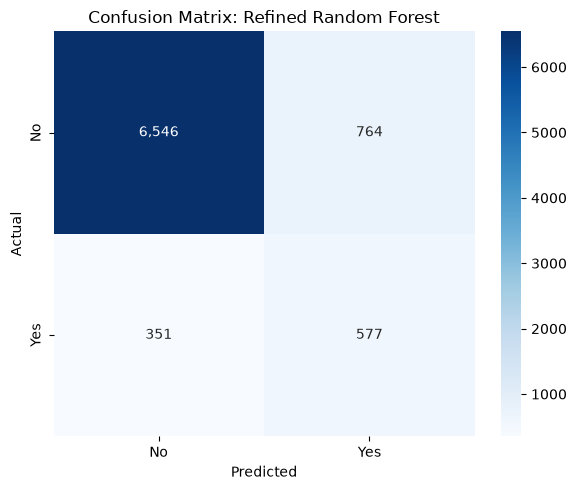

In [669]:
# Confusion Matrix
matrix = confusion_matrix(y_test, y_pred)
print(matrix)

# Plot the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(matrix, annot=True, fmt=',.0f', cmap='Blues', xticklabels=['No','Yes'], yticklabels=['No', 'Yes'])
plt.title('Confusion Matrix: Refined Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

14.4 Final model evaluation summary\
\
The refined Random Forest achieved an F1 score of 0.509 for subscribed customers on the unseen test dataset, with precision of 0.430 and recall of 0.622. The confusion matrix also supported these results showing that the model correctly identified 577 out of 928 customers who subscribed, while 351 subscribers were not identified. There were also 764 customers incorrectly predicted as subscribers.\
Although the overall accuracy was 86.5%, the F1 score, precision and recall for the subscribed class provide a more meaningful evaluation due to the class imbalance.

### 15. Summary and Conclusion

Three classification models were evaluated and improved through hyperparameter tuning and class weighing. All three models achieved higher mean CV F1 scores after tuning with the refined Random Forest achieving the highest score of 0.4811 and therefore being selected as the final model.\
\
The final evaluation showed that the model was able to identify a proportion of customers who subscribed, although the results also showed limitations in predicting the minority class. Further improvement could investigate alternative approaches to class imbalance, such as SMOTE, and the use of a pipeline to integrate preprocessing and resampling within cross validation.

For full conclusions and details, see the main report document.